In [2]:
pip install --upgrade pip && pip install "numpy==1.26.4" snntorch h5py scikit-learn matplotlib

  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0
    Uninstalling pip-25.0:
      Successfully uninstalled pip-25.0
  Using cached snntorch-0.9.4-py2.py3-none-any.whl.metadata (15 kB)
Using cached snntorch-0.9.4-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


# === MODEL ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=16, num_classes=5, beta=0.5):
        super().__init__()

        # === LIF passthrough for raw input ===
        self.lif0 = snn.Leaky(beta=beta)

        # === MLP1: Feature mixing per particle (like token MLP) ===
        self.fc1 = nn.Linear(num_features, hidden_dim)  # 3 → 16
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, num_features)  # 16 → 3
        self.lif2 = snn.Leaky(beta=beta)

        # === MLP2: Mixing across particles (channel mixing) ===
        self.fc3 = nn.Linear(num_particles, num_particles)  # 10 → 10
        self.lif3 = snn.Leaky(beta=beta)

        # === MLP3: Feature mixing again (like repeated token MLP) ===
        self.fc4 = nn.Linear(num_features, hidden_dim)  # 3 → 16
        self.lif4 = snn.Leaky(beta=beta)
        self.fc5 = nn.Linear(hidden_dim, num_features)  # 16 → 3
        self.lif5 = snn.Leaky(beta=beta)

        # === MLP4: Reduce over particle dimension ===
        self.fc6 = nn.Linear(num_particles, 1)  # 10 → 1
        self.lif6 = snn.Leaky(beta=beta)

        # === HEAD: Fully connected classifier ===
        self.fc7 = nn.Linear(num_features, hidden_dim)    # 3 → 16
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, hidden_dim)      # 16 → 16
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(hidden_dim, hidden_dim)      # 16 → 16
        self.lif9 = snn.Leaky(beta=beta)
        self.fc10 = nn.Linear(hidden_dim, num_classes)    # 16 → 5
        self.lif10 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        B = x.shape[0]
        spikes_out = []

        # === Initialize trace and membrane state tracking ===
        traces = {k: [] for k in [f"lif{i}" for i in range(11)]}
        mem = {f"mem{i}": getattr(self, f"lif{i}").init_leaky() for i in range(11)}

        for _ in range(num_steps):
            # === LIF passthrough of raw input ===
            spk0, mem['mem0'] = self.lif0(x, mem['mem0'])
            traces['lif0'].append(spk0.sum(dim=(1, 2)).detach().cpu().numpy())

            # === MLP1 ===
            x1 = self.fc1(x)
            spk1, mem['mem1'] = self.lif1(x1, mem['mem1'])
            traces['lif1'].append(spk1.sum(dim=(1, 2)).detach().cpu().numpy())

            x2 = self.fc2(spk1)
            spk2, mem['mem2'] = self.lif2(x2, mem['mem2'])
            traces['lif2'].append(spk2.sum(dim=(1, 2)).detach().cpu().numpy())

            # === MLP2 ===
            x2t = spk2.permute(0, 2, 1)
            x3 = self.fc3(x2t)
            spk3, mem['mem3'] = self.lif3(x3, mem['mem3'])
            traces['lif3'].append(spk3.sum(dim=(1, 2)).detach().cpu().numpy())
            x3_out = spk3.permute(0, 2, 1)

            # === Residual Add ===
            x4 = spk0 + x3_out

            # === MLP3 ===
            x5 = self.fc4(x4)
            spk4, mem['mem4'] = self.lif4(x5, mem['mem4'])
            traces['lif4'].append(spk4.sum(dim=(1, 2)).detach().cpu().numpy())

            x6 = self.fc5(spk4)
            spk5, mem['mem5'] = self.lif5(x6, mem['mem5'])
            traces['lif5'].append(spk5.sum(dim=(1, 2)).detach().cpu().numpy())

            # === MLP4 ===
            x6t = spk5.permute(0, 2, 1)
            x7 = self.fc6(x6t)
            spk6, mem['mem6'] = self.lif6(x7, mem['mem6'])
            traces['lif6'].append(spk6.sum(dim=(1, 2)).detach().cpu().numpy())

            # === HEAD ===
            x8 = spk6.squeeze(-1)
            x9 = self.fc7(x8)
            spk7, mem['mem7'] = self.lif7(x9, mem['mem7'])
            traces['lif7'].append(spk7.sum(dim=1).detach().cpu().numpy())

            x10 = self.fc8(spk7)
            spk8, mem['mem8'] = self.lif8(x10, mem['mem8'])
            traces['lif8'].append(spk8.sum(dim=1).detach().cpu().numpy())

            x11 = self.fc9(spk8)
            spk9, mem['mem9'] = self.lif9(x11, mem['mem9'])
            traces['lif9'].append(spk9.sum(dim=1).detach().cpu().numpy())

            x12 = self.fc10(spk9)
            spk10, mem['mem10'] = self.lif10(x12, mem['mem10'])
            traces['lif10'].append(spk10.sum(dim=1).detach().cpu().numpy())

            spikes_out.append(spk10)

        # === Final output ===
        spikes_out = torch.stack(spikes_out, dim=2)  # (B, num_classes, T)
        traces = {k: np.stack(v, axis=1) for k, v in traces.items()}
        return spikes_out, traces


✅ Loading cached constituent dataset...
🔄 Loading checkpoint from checkpoints_MLPSNNMixer1/epoch_100.pt


/tmp/ipykernel_110/2439883217.py:180: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_ckpt, map_location=device)
Evaluating: 100%|██████████| 26

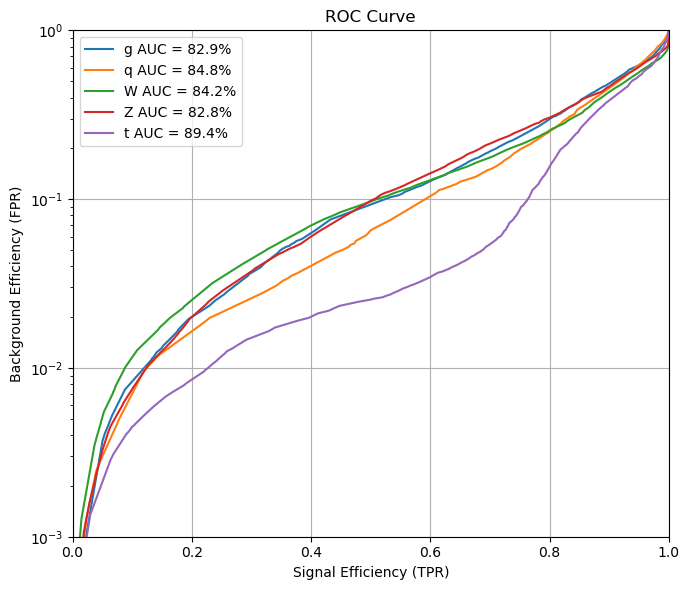

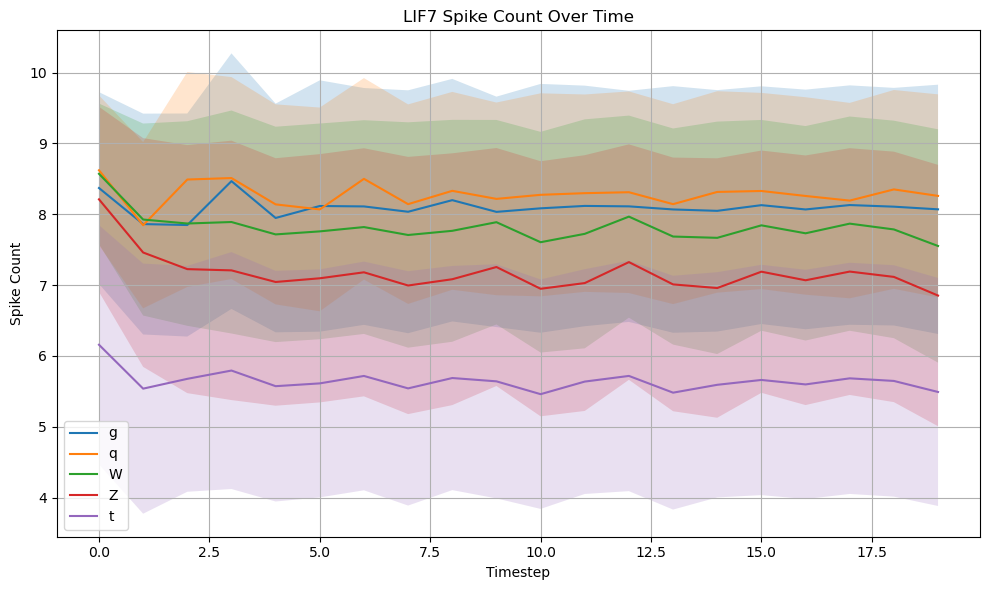

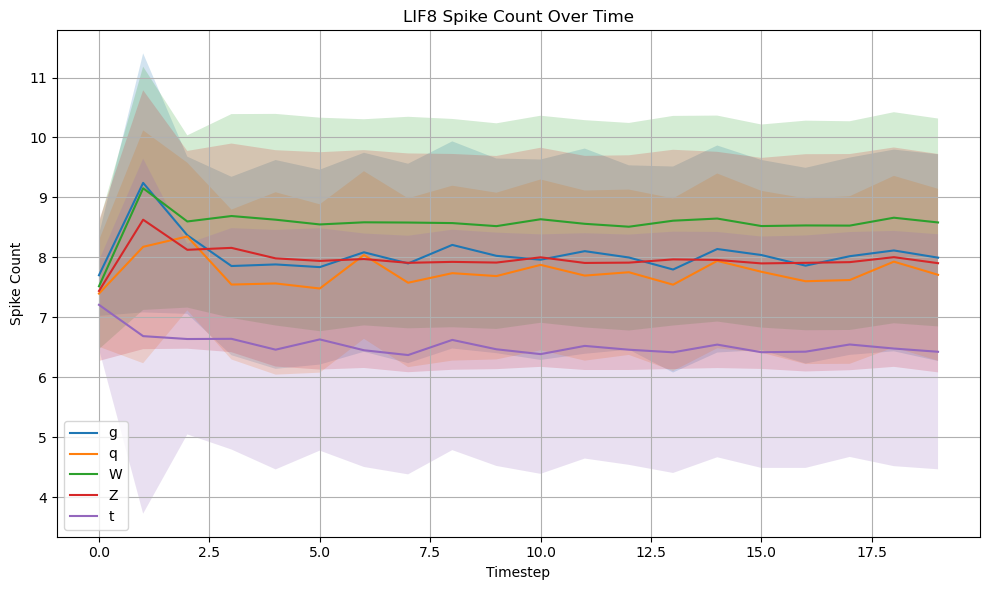

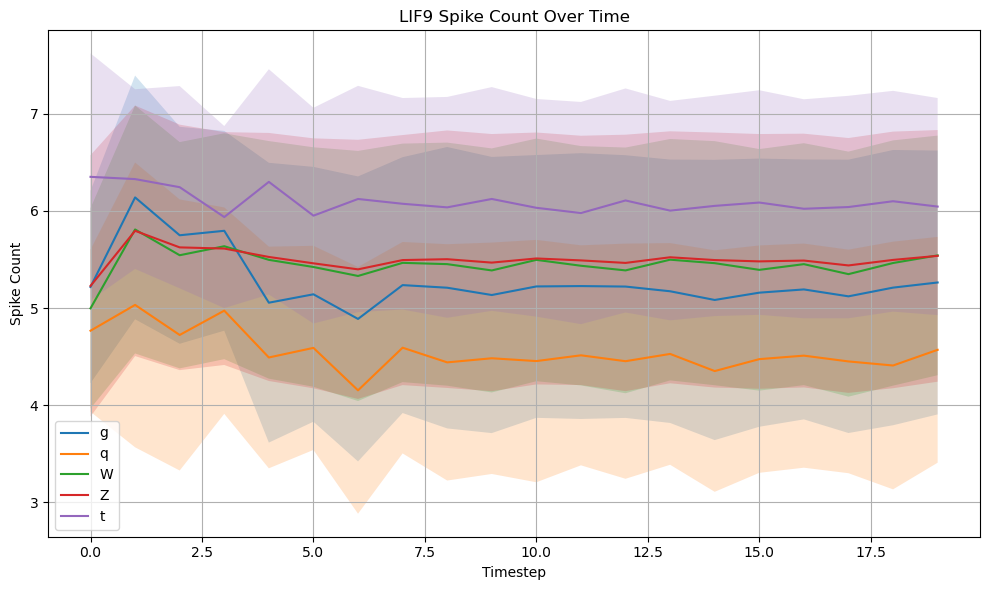

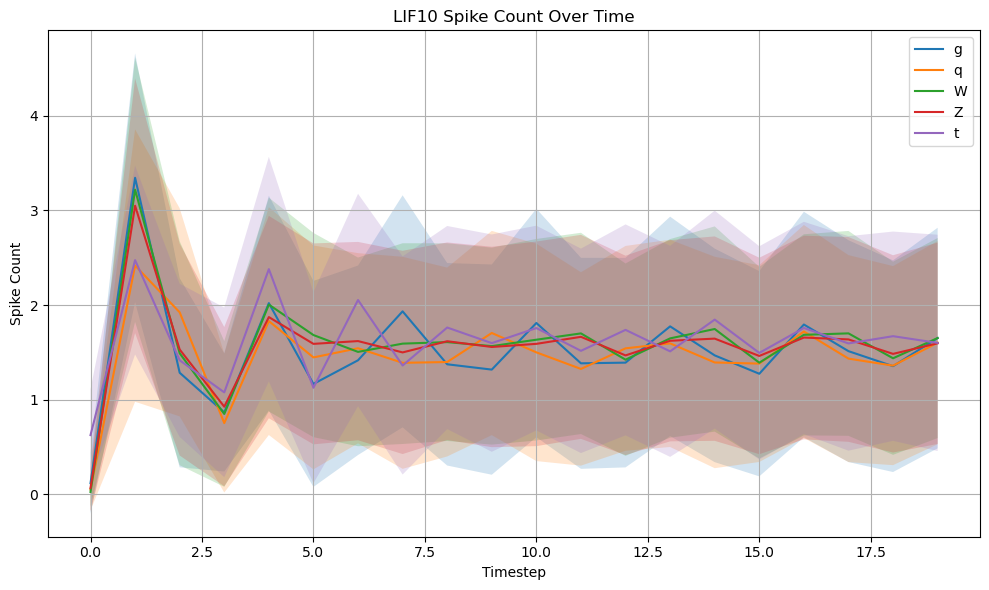

In [3]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from glob import glob
from tqdm import tqdm

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CHECKPOINT_DIR = "checkpoints_MLPSNNMixer1"
RESULT_PATH = "results/MLPSNNMixer1.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
NUM_TIMESTEPS = 20
BATCH_SIZE = 1024
NUM_EPOCHS = 100
PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === TRAINING STATE ===
start_epoch = 0
best_loss = float('inf')
early_counter = 0

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)
                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad)
                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

# === NORMALIZE ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)

# === TORCH DATASETS ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

# === MODEL ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=16, num_classes=5, beta=0.5):
        super().__init__()
        self.fc1 = nn.Linear(num_features, hidden_dim)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, num_features)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc3 = nn.Linear(num_particles, num_particles)
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(num_features, hidden_dim)
        self.lif4 = snn.Leaky(beta=beta)
        self.fc5 = nn.Linear(hidden_dim, num_features)
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(num_particles, 1)
        self.lif6 = snn.Leaky(beta=beta)
        self.fc7 = nn.Linear(num_features, hidden_dim)
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, hidden_dim)
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(hidden_dim, hidden_dim)
        self.lif9 = snn.Leaky(beta=beta)
        self.fc10 = nn.Linear(hidden_dim, num_classes)
        self.lif10 = snn.Leaky(beta=beta)
        self.lif0 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        B = x.shape[0]
        spikes_out = []
        traces = {k: [] for k in [f"lif{i}" for i in range(11)]}

        mem = {f"mem{i}": getattr(self, f"lif{i}").init_leaky() for i in range(11)}

        for _ in range(num_steps):
            spk0, mem['mem0'] = self.lif0(x, mem['mem0'])
            traces['lif0'].append(spk0.sum(dim=(1, 2)).detach().cpu().numpy())

            x1 = self.fc1(x)
            spk1, mem['mem1'] = self.lif1(x1, mem['mem1'])
            traces['lif1'].append(spk1.sum(dim=(1, 2)).detach().cpu().numpy())

            x2 = self.fc2(spk1)
            spk2, mem['mem2'] = self.lif2(x2, mem['mem2'])
            traces['lif2'].append(spk2.sum(dim=(1, 2)).detach().cpu().numpy())

            x2t = spk2.permute(0, 2, 1)
            x3 = self.fc3(x2t)
            spk3, mem['mem3'] = self.lif3(x3, mem['mem3'])
            traces['lif3'].append(spk3.sum(dim=(1, 2)).detach().cpu().numpy())
            x3_out = spk3.permute(0, 2, 1)

            x4 = spk0 + x3_out
            x5 = self.fc4(x4)
            spk4, mem['mem4'] = self.lif4(x5, mem['mem4'])
            traces['lif4'].append(spk4.sum(dim=(1, 2)).detach().cpu().numpy())

            x6 = self.fc5(spk4)
            spk5, mem['mem5'] = self.lif5(x6, mem['mem5'])
            traces['lif5'].append(spk5.sum(dim=(1, 2)).detach().cpu().numpy())

            x6t = spk5.permute(0, 2, 1)
            x7 = self.fc6(x6t)
            spk6, mem['mem6'] = self.lif6(x7, mem['mem6'])
            traces['lif6'].append(spk6.sum(dim=(1, 2)).detach().cpu().numpy())

            x8 = spk6.squeeze(-1)
            x9 = self.fc7(x8)
            spk7, mem['mem7'] = self.lif7(x9, mem['mem7'])
            traces['lif7'].append(spk7.sum(dim=1).detach().cpu().numpy())

            x10 = self.fc8(spk7)
            spk8, mem['mem8'] = self.lif8(x10, mem['mem8'])
            traces['lif8'].append(spk8.sum(dim=1).detach().cpu().numpy())

            x11 = self.fc9(spk8)
            spk9, mem['mem9'] = self.lif9(x11, mem['mem9'])
            traces['lif9'].append(spk9.sum(dim=1).detach().cpu().numpy())

            x12 = self.fc10(spk9)
            spk10, mem['mem10'] = self.lif10(x12, mem['mem10'])
            traces['lif10'].append(spk10.sum(dim=1).detach().cpu().numpy())

            spikes_out.append(spk10)

        spikes_out = torch.stack(spikes_out, dim=2)
        traces = {k: np.stack(v, axis=1) for k, v in traces.items()}
        return spikes_out, traces

# === MODEL INIT ===
model = MLPMixerSNNHybrid().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# === LOAD CHECKPOINT IF AVAILABLE ===
checkpoint_files = sorted(glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pt")))
if checkpoint_files:
    latest_ckpt = checkpoint_files[-1]
    print(f"🔄 Loading checkpoint from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
else:
    print("ℹ️ No checkpoint found, starting from scratch.")


# === TRAINING LOOP ===
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack, _ = model(xb)
        out = out_stack.sum(dim=2)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc=f"Epoch {epoch+1} Validation"):
            xb, yb = xb.to(device), yb.to(device)
            out_stack, _ = model(xb)
            out = out_stack.sum(dim=2)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
    }, os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt"))

    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break
# === INFERENCE ===
y_pred, y_true_all = [], []
spike_logs = {k: [] for k in ["lif7", "lif8", "lif9", "lif10"]}

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out_stack, traces = model(xb)
        out = out_stack.sum(dim=2)
        y_pred.append(F.softmax(out, dim=1).cpu().numpy())
        y_true_all.append(yb.numpy())
        for k in spike_logs:
            spike_logs[k].append(traces[k])

y_pred = np.concatenate(y_pred, axis=0)
y_true = np.concatenate(y_true_all, axis=0)
y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
for k in spike_logs:
    spike_logs[k] = np.concatenate(spike_logs[k], axis=0)

# === SAVE
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_true_onehot, y_score=y_pred)

# === ROC CURVE
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, label=f"{name} AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === SPIKE PLOTS
for layer, data in spike_logs.items():
    plt.figure(figsize=(10, 6))
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_spikes = data[y_true == class_idx]
        mean = class_spikes.mean(axis=0)
        std = class_spikes.std(axis=0)
        plt.plot(mean, label=class_name)
        plt.fill_between(range(NUM_TIMESTEPS), mean - std, mean + std, alpha=0.2)
    plt.title(f"{layer.upper()} Spike Count Over Time")
    plt.xlabel("Timestep")
    plt.ylabel("Spike Count")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


MLPSNN

✅ Loading cached constituent dataset...


/tmp/ipykernel_108/3249648061.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_ckpt, map_location=device)


🔄 Loading checkpoint from checkpoints_MLPSNNMixer_complex/epoch_085.pt


Epoch 86 Validation: 100%|██████████| 264/264 [00:34<00:00,  7.73it/s]


Epoch 86 | Val Loss: 0.9955 | Val Acc: 0.6205


...

Epoch 99 Validation: 100%|██████████| 264/264 [00:33<00:00,  7.92it/s]


Epoch 99 | Val Loss: 0.9826 | Val Acc: 0.6356


Epoch 100 Validation: 100%|██████████| 264/264 [00:33<00:00,  7.80it/s]


Epoch 100 | Val Loss: 0.9876 | Val Acc: 0.6258


Evaluating: 100%|██████████| 264/264 [00:33<00:00,  7.95it/s]


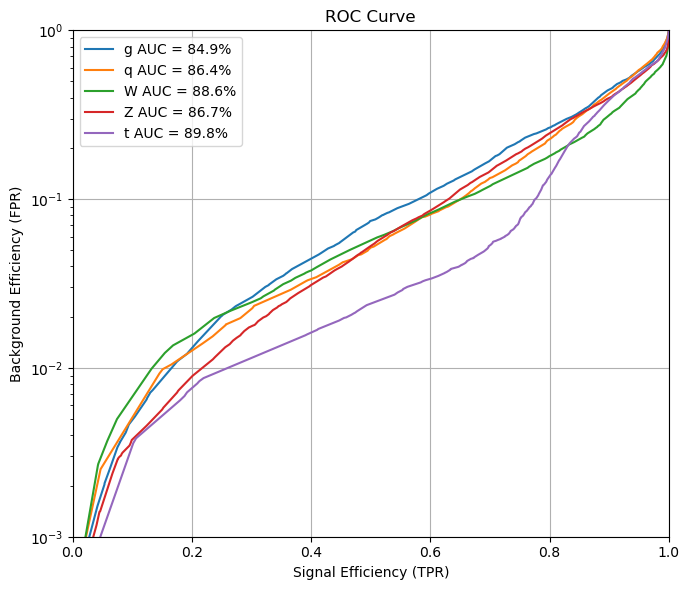

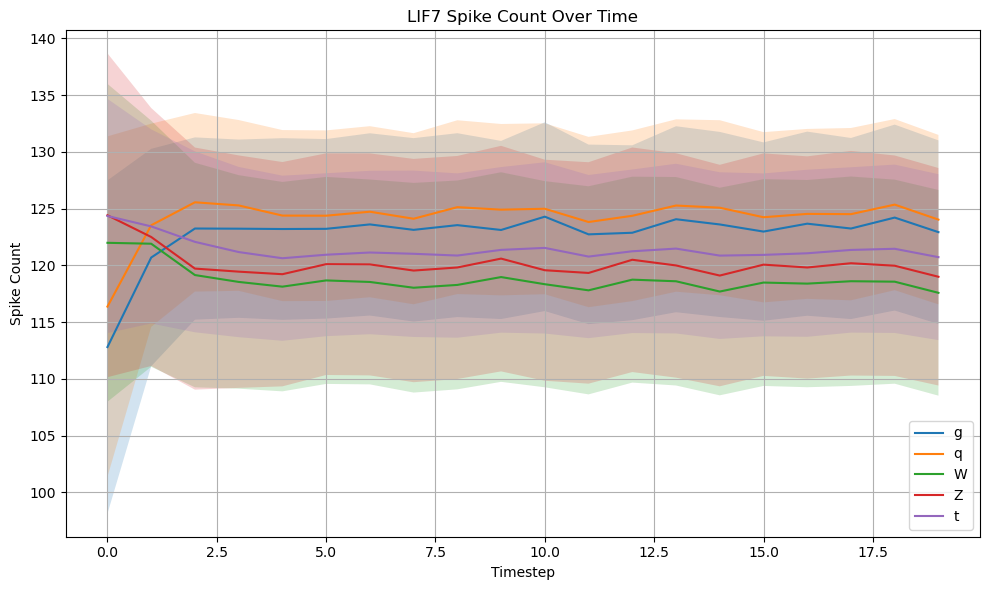

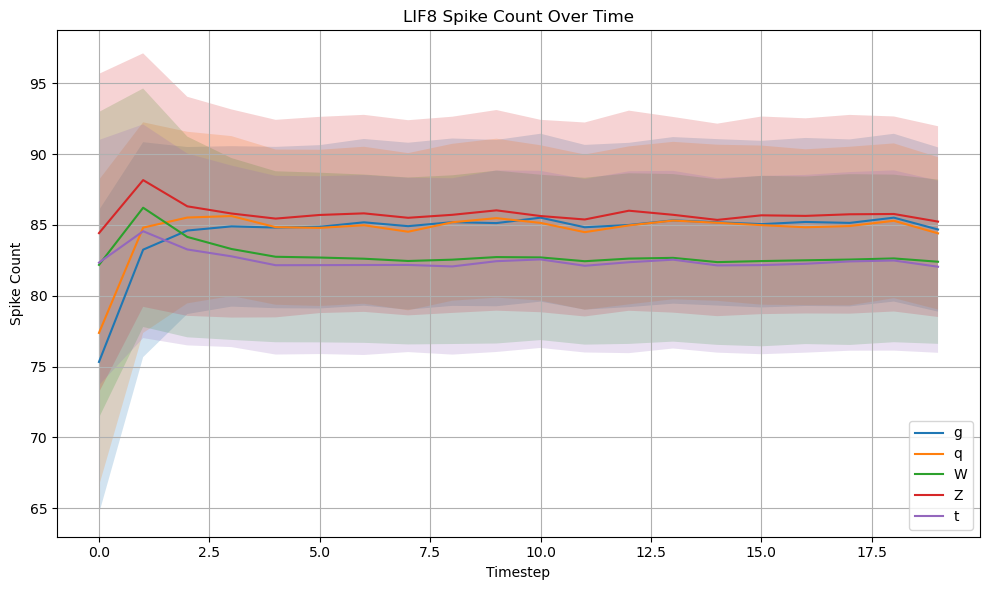

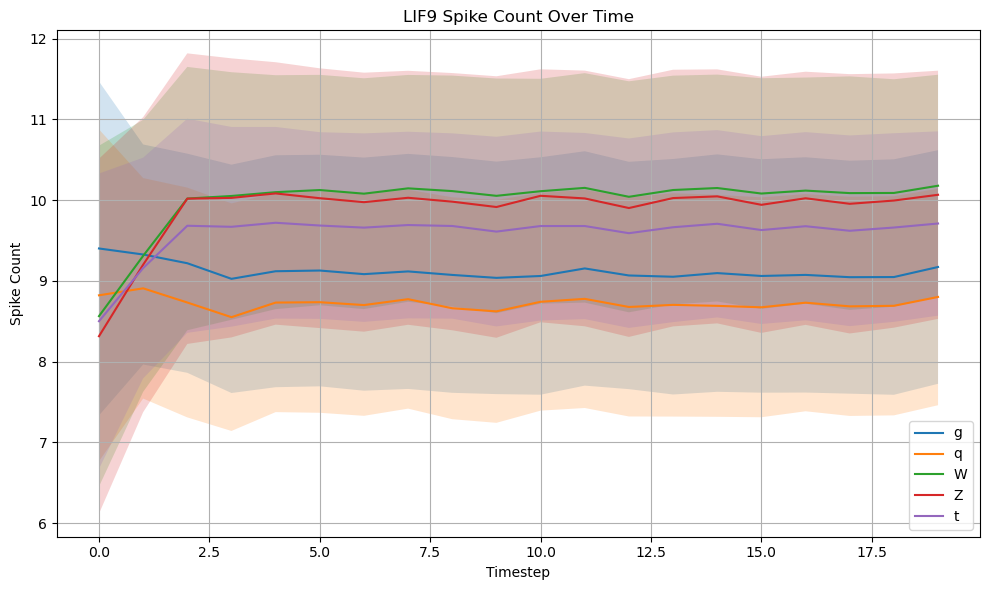

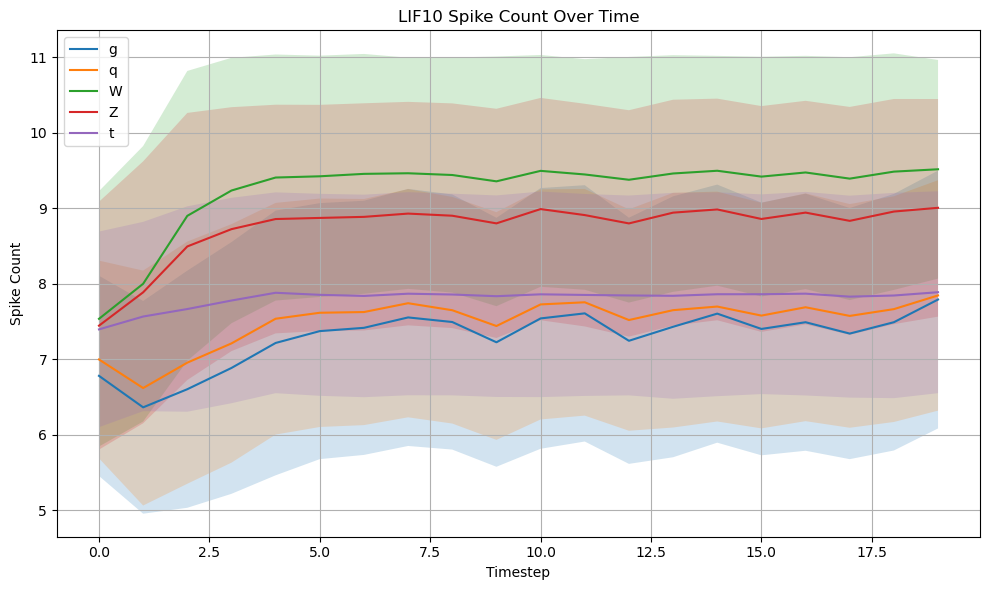

In [6]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from glob import glob
from tqdm import tqdm

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CHECKPOINT_DIR = "checkpoints_MLPSNNMixer_complex"
RESULT_PATH = "results/MLPSNNMixer_complex.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
NUM_TIMESTEPS = 20
BATCH_SIZE = 1024
NUM_EPOCHS = 100
PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === TRAINING STATE ===
start_epoch = 0
best_loss = float('inf')
early_counter = 0

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)
                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad)
                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

# === NORMALIZE ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)

# === TORCH DATASETS ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

# === UPDATED MODEL ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=16, num_classes=5, beta=0.5):
        super().__init__()

        # === Embedding Layer: 3 → 16 ===
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.lif0 = snn.Leaky(beta=beta)

        # === MLP1: Per-particle feature mixing ===
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif2 = snn.Leaky(beta=beta)

        # === MLP2: Mixing across particles ===
        self.fc3 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif4 = snn.Leaky(beta=beta)

        # === MLP3: Repeated per-particle mixing ===
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif6 = snn.Leaky(beta=beta)

        # === MLP4: Reduce across particles ===
        self.fc7 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(num_particles, 1)           # 10 → 1
        self.lif9 = snn.Leaky(beta=beta)

        # === HEAD: Fully connected classifier ===
        self.fc10 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif10 = snn.Leaky(beta=beta)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif11 = snn.Leaky(beta=beta)
        self.fc12 = nn.Linear(hidden_dim, num_classes)  # 16 → 5
        self.lif12 = snn.Leaky(beta=beta)
    
    def forward(self, x, num_steps=20):
        B = x.shape[0]
        spikes_out = []
    
        # === Initialize membrane states for all LIFs ===
        mem = {f"lif{i}": getattr(self, f"lif{i}").init_leaky() for i in range(13)}
    
        # === Initialize spike traces ===
        traces = {f"lif{i}": [] for i in range(13)}
    
        for _ in range(num_steps):
            # === Embedding ===
            x0 = self.embedding(x)
            spk0, mem['lif0'] = self.lif0(x0, mem['lif0'])
            traces['lif0'].append(spk0.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP1 ===
            x1 = self.fc1(spk0)
            spk1, mem['lif1'] = self.lif1(x1, mem['lif1'])
            traces['lif1'].append(spk1.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x2 = self.fc2(spk1)
            spk2, mem['lif2'] = self.lif2(x2, mem['lif2'])
            traces['lif2'].append(spk2.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP2 ===
            x2t = spk2.permute(0, 2, 1)
            x3 = self.fc3(x2t)
            spk3, mem['lif3'] = self.lif3(x3, mem['lif3'])
            traces['lif3'].append(spk3.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4 = self.fc4(spk3)
            spk4, mem['lif4'] = self.lif4(x4, mem['lif4'])
            traces['lif4'].append(spk4.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4_out = spk4.permute(0, 2, 1)
    
            # === Residual Add ===
            x5 = spk0 + x4_out
    
            # === MLP3 ===
            x6 = self.fc5(x5)
            spk5, mem['lif5'] = self.lif5(x6, mem['lif5'])
            traces['lif5'].append(spk5.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x7 = self.fc6(spk5)
            spk6, mem['lif6'] = self.lif6(x7, mem['lif6'])
            traces['lif6'].append(spk6.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP4 ===
            x7t = spk6.permute(0, 2, 1)
            x8 = self.fc7(x7t)
            spk7, mem['lif7'] = self.lif7(x8, mem['lif7'])
            traces['lif7'].append(spk7.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x9 = self.fc8(spk7)
            spk8, mem['lif8'] = self.lif8(x9, mem['lif8'])
            traces['lif8'].append(spk8.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x10 = self.fc9(spk8)
            spk9, mem['lif9'] = self.lif9(x10, mem['lif9'])
            traces['lif9'].append(spk9.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === HEAD ===
            x11 = spk9.squeeze(-1)
            x12 = self.fc10(x11)
            spk10, mem['lif10'] = self.lif10(x12, mem['lif10'])
            traces['lif10'].append(spk10.sum(dim=1).detach().cpu().numpy())
    
            x13 = self.fc11(spk10)
            spk11, mem['lif11'] = self.lif11(x13, mem['lif11'])
            traces['lif11'].append(spk11.sum(dim=1).detach().cpu().numpy())
    
            x14 = self.fc12(spk11)
            spk12, mem['lif12'] = self.lif12(x14, mem['lif12'])
            traces['lif12'].append(spk12.sum(dim=1).detach().cpu().numpy())
    
            spikes_out.append(spk12)
    
        # Stack time axis for output and traces
        spikes_out = torch.stack(spikes_out, dim=2)  # (B, 5, T)
        traces = {k: np.stack(v, axis=1) for k, v in traces.items()}  # (B, T) per layer
    
        return spikes_out, traces

# === MODEL INIT ===
model = MLPMixerSNNHybrid().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# === LOAD CHECKPOINT IF AVAILABLE ===
checkpoint_files = sorted(glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pt")))
if checkpoint_files:
    latest_ckpt = checkpoint_files[-1]
    print(f"🔄 Loading checkpoint from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
else:
    print("ℹ️ No checkpoint found, starting from scratch.")


# === TRAINING LOOP ===
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack, _ = model(xb)
        out = out_stack.sum(dim=2)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc=f"Epoch {epoch+1} Validation"):
            xb, yb = xb.to(device), yb.to(device)
            out_stack, _ = model(xb)
            out = out_stack.sum(dim=2)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
    }, os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt"))

    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break
# === INFERENCE ===
y_pred, y_true_all = [], []
spike_logs = {k: [] for k in ["lif7", "lif8", "lif9", "lif10"]}

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out_stack, traces = model(xb)
        out = out_stack.sum(dim=2)
        y_pred.append(F.softmax(out, dim=1).cpu().numpy())
        y_true_all.append(yb.numpy())
        for k in spike_logs:
            spike_logs[k].append(traces[k])

y_pred = np.concatenate(y_pred, axis=0)
y_true = np.concatenate(y_true_all, axis=0)
y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
for k in spike_logs:
    spike_logs[k] = np.concatenate(spike_logs[k], axis=0)

# === SAVE
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_true_onehot, y_score=y_pred)

# === ROC CURVE
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, label=f"{name} AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === SPIKE PLOTS
for layer, data in spike_logs.items():
    plt.figure(figsize=(10, 6))
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_spikes = data[y_true == class_idx]
        mean = class_spikes.mean(axis=0)
        std = class_spikes.std(axis=0)
        plt.plot(mean, label=class_name)
        plt.fill_between(range(NUM_TIMESTEPS), mean - std, mean + std, alpha=0.2)
    plt.title(f"{layer.upper()} Spike Count Over Time")
    plt.xlabel("Timestep")
    plt.ylabel("Spike Count")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


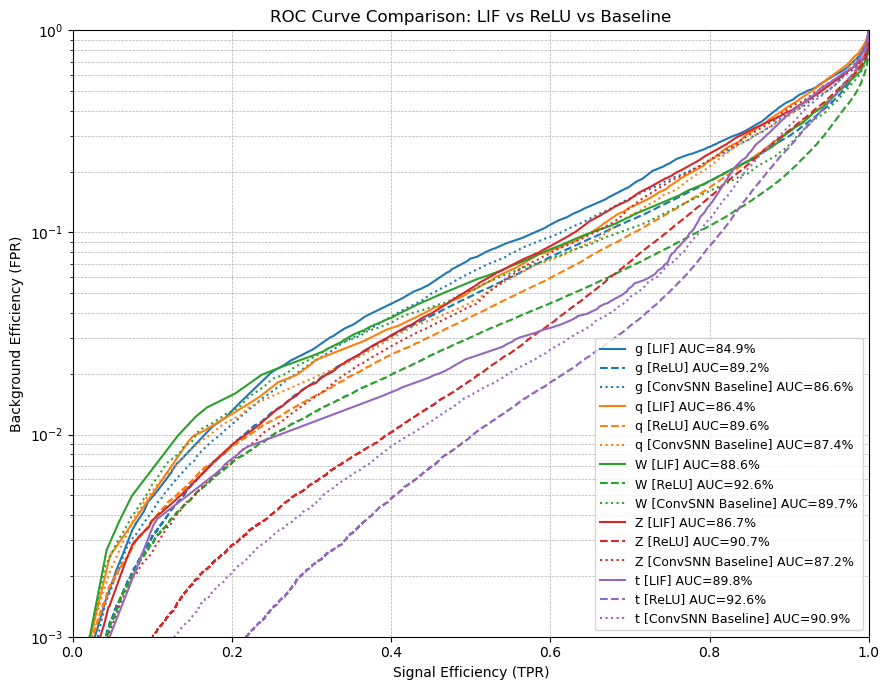

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# === CONFIG ===
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
RESULTS_FILES = {
    "LIF": "results/MLPSNNMixer_complex.npz",
    "ReLU": "results/MLPMixerRELU_complex.npz",
    "ConvSNN Baseline": "results/snn_results_constituents.npz"
}
LINE_STYLES = {
    "LIF": '-',
    "ReLU": '--',
    "ConvSNN Baseline": ':'
}
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# === LOAD ALL RESULTS ===
results = {}
for label, path in RESULTS_FILES.items():
    data = np.load(path)
    results[label] = {
        "y_true": data["y_true"],
        "y_score": data["y_score"]
    }

# === PLOT ===
plt.figure(figsize=(9, 7))

for class_idx, class_name in enumerate(CLASS_NAMES):
    for model_idx, (model_label, model_data) in enumerate(results.items()):
        y_true = model_data["y_true"][:, class_idx]
        y_score = model_data["y_score"][:, class_idx]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_score = auc(fpr, tpr)

        plt.plot(
            tpr, fpr,
            linestyle=LINE_STYLES[model_label],
            color=COLORS[class_idx],
            label=f"{class_name} [{model_label}] AUC={auc_score:.1%}"
        )

plt.yscale('log')
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("ROC Curve Comparison: LIF vs ReLU vs Baseline")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


hidden_dim=64

✅ Loading cached constituent dataset...
ℹ️ No checkpoint found, starting from scratch.


Epoch 1 Validation: 100%|██████████| 264/264 [01:00<00:00,  4.36it/s]


Epoch 1 | Val Loss: 1.0874 | Val Acc: 0.5850


Epoch 2 Validation: 100%|██████████| 264/264 [01:03<00:00,  4.13it/s]


Epoch 2 | Val Loss: 1.0412 | Val Acc: 0.6127


...

IOPub message rate exceeded.█████▊| 584/596 [03:38<00:03,  3.02it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch 63 Validation: 100%|██████████| 264/264 [01:00<00:00,  4.36it/s]


Epoch 63 | Val Loss: 0.8932 | Val Acc: 0.6677


Epoch 64 Validation: 100%|██████████| 264/264 [01:00<00:00,  4.37it/s]


Epoch 64 | Val Loss: 0.8969 | Val Acc: 0.6729
🛑 Early stopping triggered.


Evaluating: 100%|██████████| 264/264 [01:00<00:00,  4.36it/s]


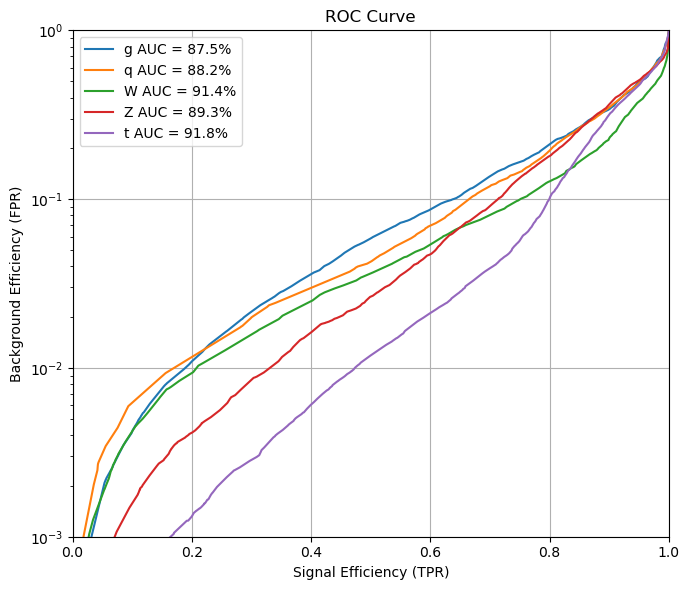

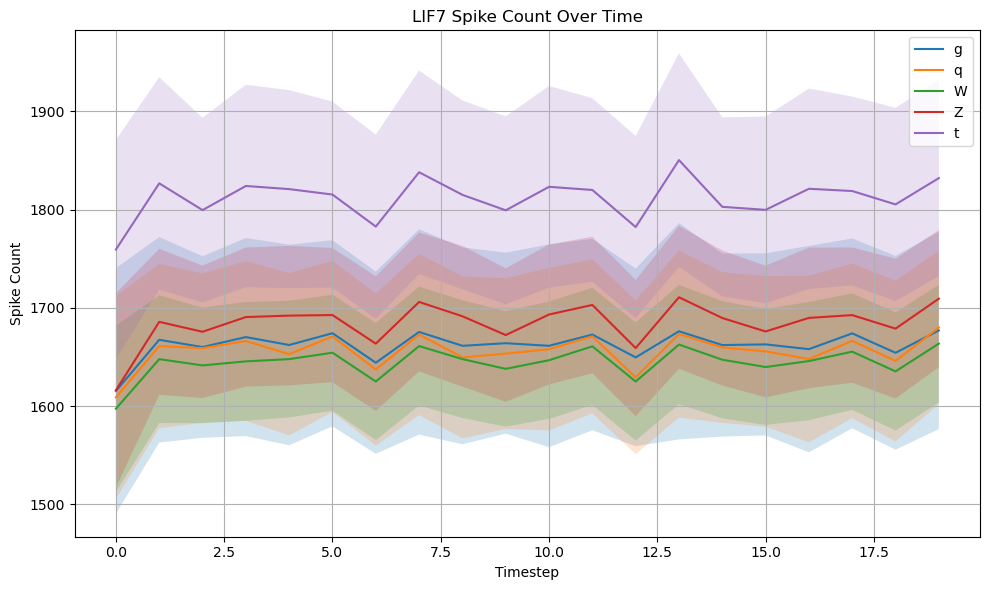

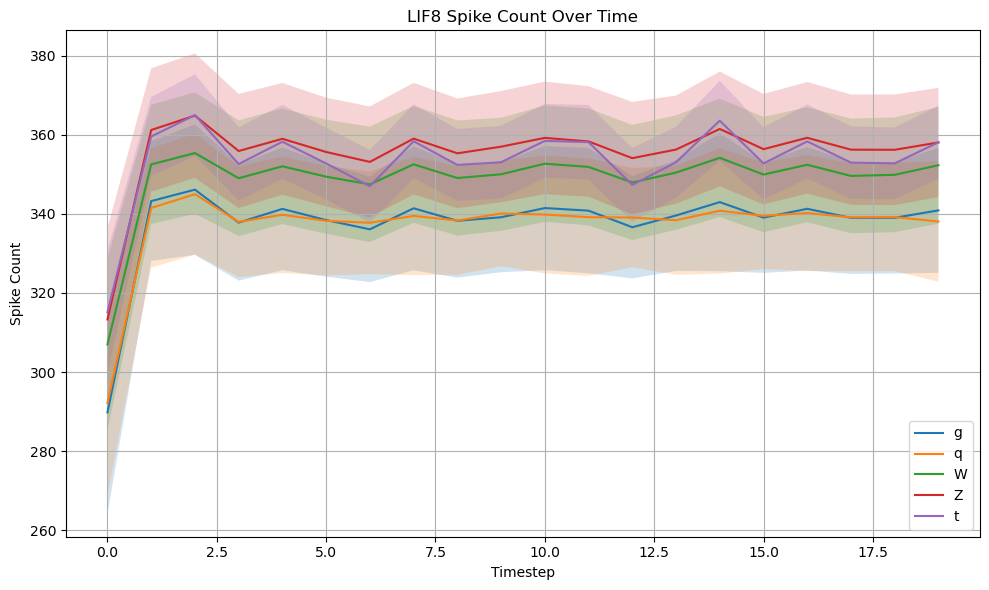

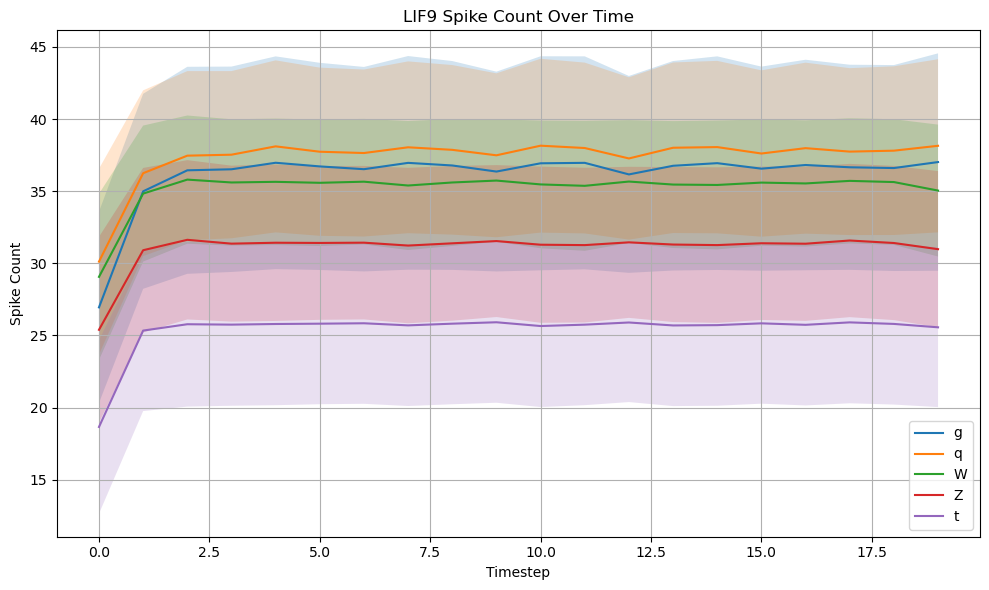

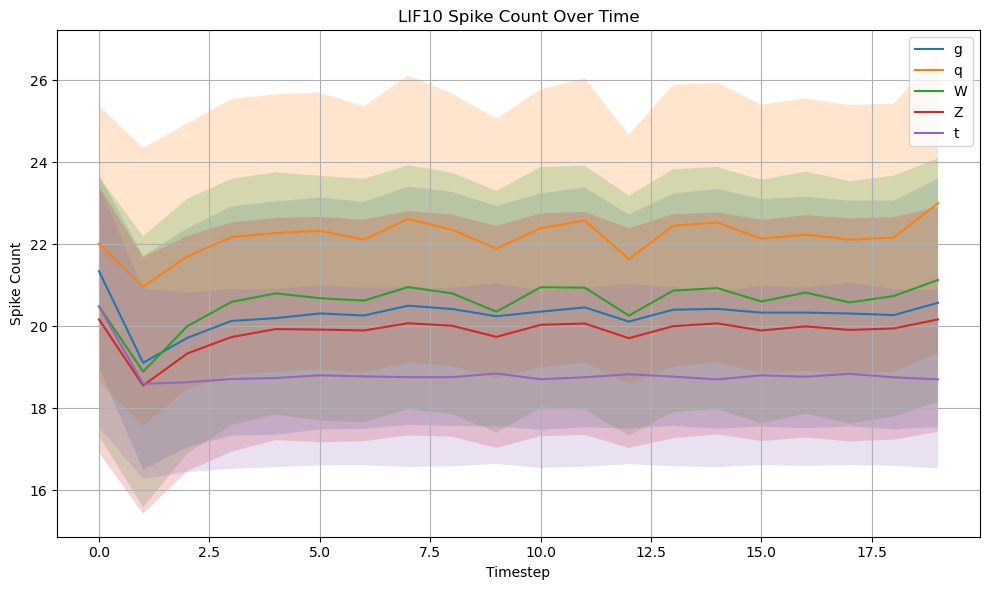

In [5]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from glob import glob
from tqdm import tqdm

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CHECKPOINT_DIR = "checkpoints_MLPSNNMixer_complex64"
RESULT_PATH = "results/MLPSNNMixer_complex64.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
NUM_TIMESTEPS = 20
BATCH_SIZE = 1024
NUM_EPOCHS = 100
PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === TRAINING STATE ===
start_epoch = 0
best_loss = float('inf')
early_counter = 0

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)
                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad)
                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

# === NORMALIZE ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)

# === TORCH DATASETS ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

# === UPDATED MODEL ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=64, num_classes=5, beta=0.5):
        super().__init__()

        # === Embedding Layer: 3 → 16 ===
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.lif0 = snn.Leaky(beta=beta)

        # === MLP1: Per-particle feature mixing ===
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif2 = snn.Leaky(beta=beta)

        # === MLP2: Mixing across particles ===
        self.fc3 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif4 = snn.Leaky(beta=beta)

        # === MLP3: Repeated per-particle mixing ===
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif6 = snn.Leaky(beta=beta)

        # === MLP4: Reduce across particles ===
        self.fc7 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(num_particles, 1)           # 10 → 1
        self.lif9 = snn.Leaky(beta=beta)

        # === HEAD: Fully connected classifier ===
        self.fc10 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif10 = snn.Leaky(beta=beta)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif11 = snn.Leaky(beta=beta)
        self.fc12 = nn.Linear(hidden_dim, num_classes)  # 16 → 5
        self.lif12 = snn.Leaky(beta=beta)
    
    def forward(self, x, num_steps=20):
        B = x.shape[0]
        spikes_out = []
    
        # === Initialize membrane states for all LIFs ===
        mem = {f"lif{i}": getattr(self, f"lif{i}").init_leaky() for i in range(13)}
    
        # === Initialize spike traces ===
        traces = {f"lif{i}": [] for i in range(13)}
    
        for _ in range(num_steps):
            # === Embedding ===
            x0 = self.embedding(x)
            spk0, mem['lif0'] = self.lif0(x0, mem['lif0'])
            traces['lif0'].append(spk0.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP1 ===
            x1 = self.fc1(spk0)
            spk1, mem['lif1'] = self.lif1(x1, mem['lif1'])
            traces['lif1'].append(spk1.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x2 = self.fc2(spk1)
            spk2, mem['lif2'] = self.lif2(x2, mem['lif2'])
            traces['lif2'].append(spk2.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP2 ===
            x2t = spk2.permute(0, 2, 1)
            x3 = self.fc3(x2t)
            spk3, mem['lif3'] = self.lif3(x3, mem['lif3'])
            traces['lif3'].append(spk3.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4 = self.fc4(spk3)
            spk4, mem['lif4'] = self.lif4(x4, mem['lif4'])
            traces['lif4'].append(spk4.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4_out = spk4.permute(0, 2, 1)
    
            # === Residual Add ===
            x5 = spk0 + x4_out
    
            # === MLP3 ===
            x6 = self.fc5(x5)
            spk5, mem['lif5'] = self.lif5(x6, mem['lif5'])
            traces['lif5'].append(spk5.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x7 = self.fc6(spk5)
            spk6, mem['lif6'] = self.lif6(x7, mem['lif6'])
            traces['lif6'].append(spk6.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP4 ===
            x7t = spk6.permute(0, 2, 1)
            x8 = self.fc7(x7t)
            spk7, mem['lif7'] = self.lif7(x8, mem['lif7'])
            traces['lif7'].append(spk7.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x9 = self.fc8(spk7)
            spk8, mem['lif8'] = self.lif8(x9, mem['lif8'])
            traces['lif8'].append(spk8.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x10 = self.fc9(spk8)
            spk9, mem['lif9'] = self.lif9(x10, mem['lif9'])
            traces['lif9'].append(spk9.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === HEAD ===
            x11 = spk9.squeeze(-1)
            x12 = self.fc10(x11)
            spk10, mem['lif10'] = self.lif10(x12, mem['lif10'])
            traces['lif10'].append(spk10.sum(dim=1).detach().cpu().numpy())
    
            x13 = self.fc11(spk10)
            spk11, mem['lif11'] = self.lif11(x13, mem['lif11'])
            traces['lif11'].append(spk11.sum(dim=1).detach().cpu().numpy())
    
            x14 = self.fc12(spk11)
            spk12, mem['lif12'] = self.lif12(x14, mem['lif12'])
            traces['lif12'].append(spk12.sum(dim=1).detach().cpu().numpy())
    
            spikes_out.append(spk12)
    
        # Stack time axis for output and traces
        spikes_out = torch.stack(spikes_out, dim=2)  # (B, 5, T)
        traces = {k: np.stack(v, axis=1) for k, v in traces.items()}  # (B, T) per layer
    
        return spikes_out, traces

# === MODEL INIT ===
model = MLPMixerSNNHybrid().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# === LOAD CHECKPOINT IF AVAILABLE ===
checkpoint_files = sorted(glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pt")))
if checkpoint_files:
    latest_ckpt = checkpoint_files[-1]
    print(f"🔄 Loading checkpoint from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
else:
    print("ℹ️ No checkpoint found, starting from scratch.")


# === TRAINING LOOP ===
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack, _ = model(xb)
        out = out_stack.sum(dim=2)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc=f"Epoch {epoch+1} Validation"):
            xb, yb = xb.to(device), yb.to(device)
            out_stack, _ = model(xb)
            out = out_stack.sum(dim=2)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
    }, os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt"))

    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break
# === INFERENCE ===
y_pred, y_true_all = [], []
spike_logs = {k: [] for k in ["lif7", "lif8", "lif9", "lif10"]}

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out_stack, traces = model(xb)
        out = out_stack.sum(dim=2)
        y_pred.append(F.softmax(out, dim=1).cpu().numpy())
        y_true_all.append(yb.numpy())
        for k in spike_logs:
            spike_logs[k].append(traces[k])

y_pred = np.concatenate(y_pred, axis=0)
y_true = np.concatenate(y_true_all, axis=0)
y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
for k in spike_logs:
    spike_logs[k] = np.concatenate(spike_logs[k], axis=0)

# === SAVE
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_true_onehot, y_score=y_pred)

# === ROC CURVE
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, label=f"{name} AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === SPIKE PLOTS
for layer, data in spike_logs.items():
    plt.figure(figsize=(10, 6))
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_spikes = data[y_true == class_idx]
        mean = class_spikes.mean(axis=0)
        std = class_spikes.std(axis=0)
        plt.plot(mean, label=class_name)
        plt.fill_between(range(NUM_TIMESTEPS), mean - std, mean + std, alpha=0.2)
    plt.title(f"{layer.upper()} Spike Count Over Time")
    plt.xlabel("Timestep")
    plt.ylabel("Spike Count")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [1]:
hidden_dim = 128

✅ Loading cached constituent dataset...
🔄 Loading checkpoint from checkpoints_MLPSNNMixer_complex128/epoch_053.pt


/tmp/ipykernel_119/2265029984.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_ckpt, map_location=device)
Epoch 54 Validation: 100%|█████

Epoch 54 | Val Loss: 0.8831 | Val Acc: 0.6753
🛑 Early stopping triggered.


Evaluating: 100%|██████████| 264/264 [01:11<00:00,  3.68it/s]


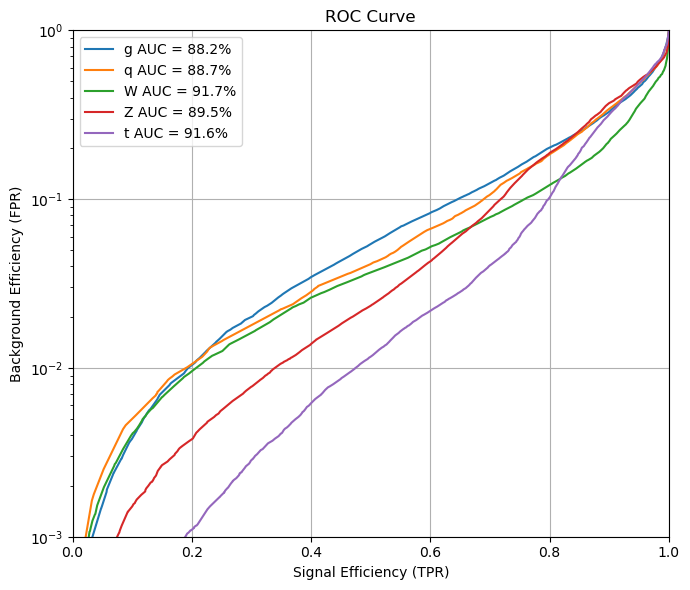

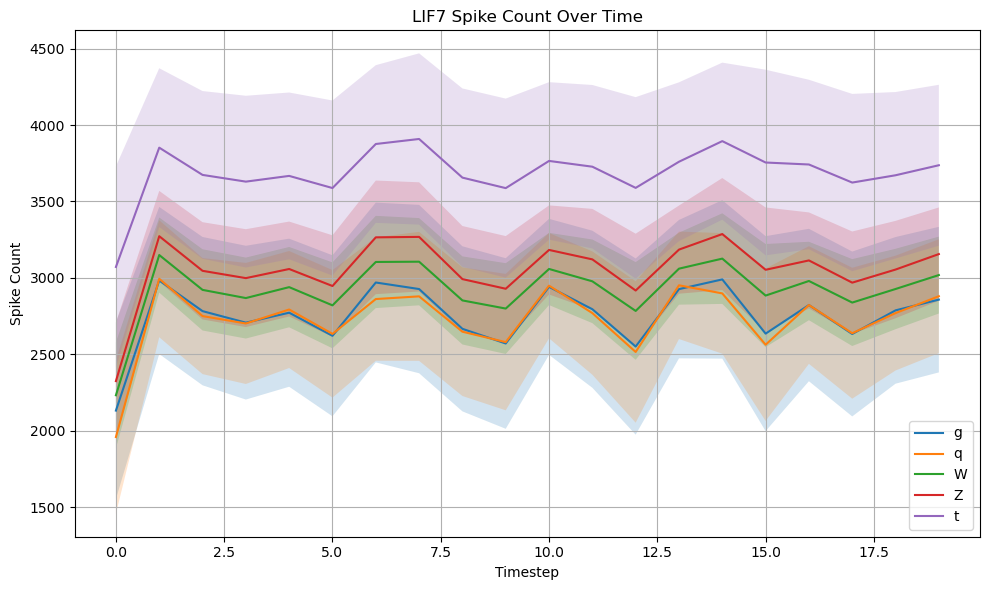

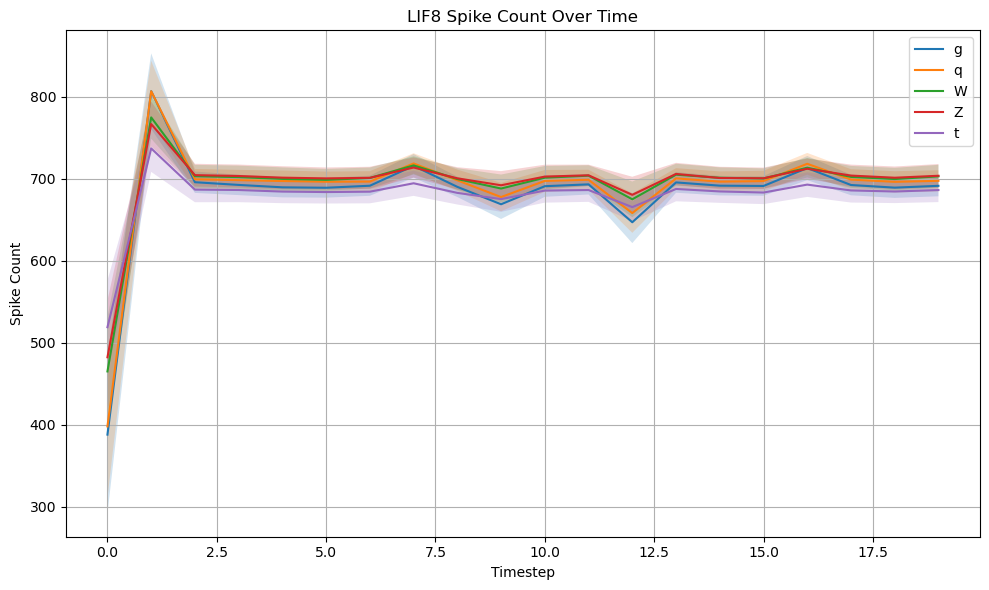

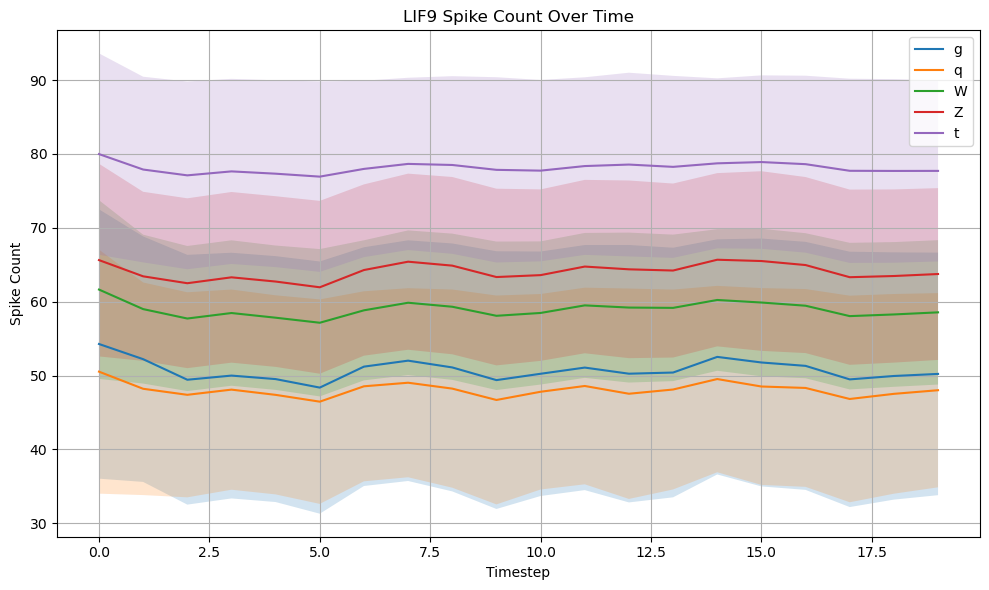

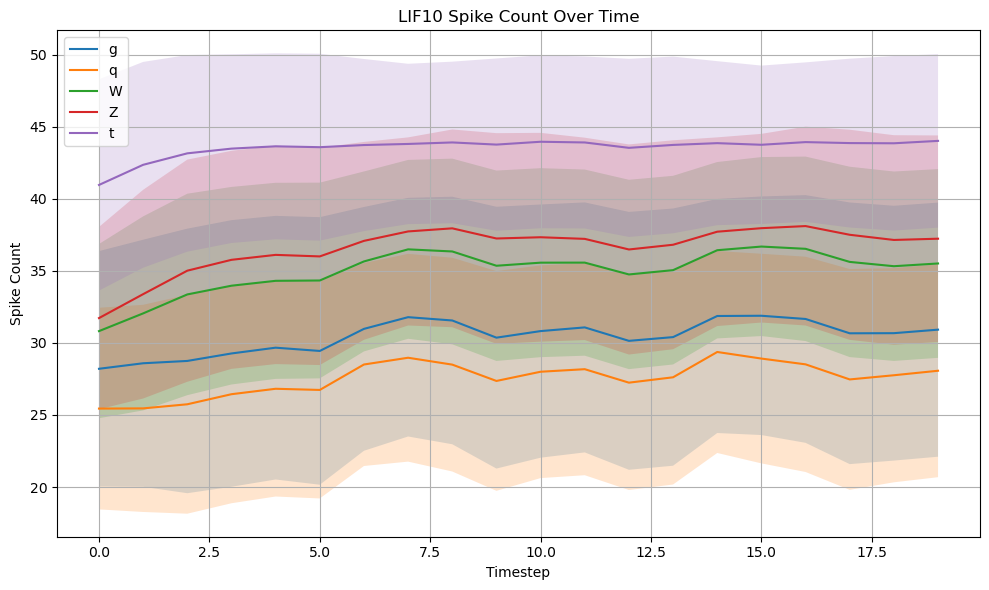

In [2]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from glob import glob
from tqdm import tqdm

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CHECKPOINT_DIR = "checkpoints_MLPSNNMixer_complex128"
RESULT_PATH = "results/MLPSNNMixer_complex128.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
NUM_TIMESTEPS = 20
BATCH_SIZE = 1024
NUM_EPOCHS = 100
PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === TRAINING STATE ===
start_epoch = 0
best_loss = float('inf')
early_counter = 0

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)
                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad)
                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

# === NORMALIZE ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)

# === TORCH DATASETS ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

# === UPDATED MODEL ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=128, num_classes=5, beta=0.5):
        super().__init__()

        # === Embedding Layer: 3 → 16 ===
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.lif0 = snn.Leaky(beta=beta)

        # === MLP1: Per-particle feature mixing ===
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif2 = snn.Leaky(beta=beta)

        # === MLP2: Mixing across particles ===
        self.fc3 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif4 = snn.Leaky(beta=beta)

        # === MLP3: Repeated per-particle mixing ===
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif6 = snn.Leaky(beta=beta)

        # === MLP4: Reduce across particles ===
        self.fc7 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(num_particles, 1)           # 10 → 1
        self.lif9 = snn.Leaky(beta=beta)

        # === HEAD: Fully connected classifier ===
        self.fc10 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif10 = snn.Leaky(beta=beta)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif11 = snn.Leaky(beta=beta)
        self.fc12 = nn.Linear(hidden_dim, num_classes)  # 16 → 5
        self.lif12 = snn.Leaky(beta=beta)
    
    def forward(self, x, num_steps=20):
        B = x.shape[0]
        spikes_out = []
    
        # === Initialize membrane states for all LIFs ===
        mem = {f"lif{i}": getattr(self, f"lif{i}").init_leaky() for i in range(13)}
    
        # === Initialize spike traces ===
        traces = {f"lif{i}": [] for i in range(13)}
    
        for _ in range(num_steps):
            # === Embedding ===
            x0 = self.embedding(x)
            spk0, mem['lif0'] = self.lif0(x0, mem['lif0'])
            traces['lif0'].append(spk0.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP1 ===
            x1 = self.fc1(spk0)
            spk1, mem['lif1'] = self.lif1(x1, mem['lif1'])
            traces['lif1'].append(spk1.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x2 = self.fc2(spk1)
            spk2, mem['lif2'] = self.lif2(x2, mem['lif2'])
            traces['lif2'].append(spk2.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP2 ===
            x2t = spk2.permute(0, 2, 1)
            x3 = self.fc3(x2t)
            spk3, mem['lif3'] = self.lif3(x3, mem['lif3'])
            traces['lif3'].append(spk3.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4 = self.fc4(spk3)
            spk4, mem['lif4'] = self.lif4(x4, mem['lif4'])
            traces['lif4'].append(spk4.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4_out = spk4.permute(0, 2, 1)
    
            # === Residual Add ===
            x5 = spk0 + x4_out
    
            # === MLP3 ===
            x6 = self.fc5(x5)
            spk5, mem['lif5'] = self.lif5(x6, mem['lif5'])
            traces['lif5'].append(spk5.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x7 = self.fc6(spk5)
            spk6, mem['lif6'] = self.lif6(x7, mem['lif6'])
            traces['lif6'].append(spk6.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP4 ===
            x7t = spk6.permute(0, 2, 1)
            x8 = self.fc7(x7t)
            spk7, mem['lif7'] = self.lif7(x8, mem['lif7'])
            traces['lif7'].append(spk7.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x9 = self.fc8(spk7)
            spk8, mem['lif8'] = self.lif8(x9, mem['lif8'])
            traces['lif8'].append(spk8.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x10 = self.fc9(spk8)
            spk9, mem['lif9'] = self.lif9(x10, mem['lif9'])
            traces['lif9'].append(spk9.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === HEAD ===
            x11 = spk9.squeeze(-1)
            x12 = self.fc10(x11)
            spk10, mem['lif10'] = self.lif10(x12, mem['lif10'])
            traces['lif10'].append(spk10.sum(dim=1).detach().cpu().numpy())
    
            x13 = self.fc11(spk10)
            spk11, mem['lif11'] = self.lif11(x13, mem['lif11'])
            traces['lif11'].append(spk11.sum(dim=1).detach().cpu().numpy())
    
            x14 = self.fc12(spk11)
            spk12, mem['lif12'] = self.lif12(x14, mem['lif12'])
            traces['lif12'].append(spk12.sum(dim=1).detach().cpu().numpy())
    
            spikes_out.append(spk12)
    
        # Stack time axis for output and traces
        spikes_out = torch.stack(spikes_out, dim=2)  # (B, 5, T)
        traces = {k: np.stack(v, axis=1) for k, v in traces.items()}  # (B, T) per layer
    
        return spikes_out, traces

# === MODEL INIT ===
model = MLPMixerSNNHybrid().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# === LOAD CHECKPOINT IF AVAILABLE ===
checkpoint_files = sorted(glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pt")))
if checkpoint_files:
    latest_ckpt = checkpoint_files[-1]
    print(f"🔄 Loading checkpoint from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
else:
    print("ℹ️ No checkpoint found, starting from scratch.")


# === TRAINING LOOP ===
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack, _ = model(xb)
        out = out_stack.sum(dim=2)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc=f"Epoch {epoch+1} Validation"):
            xb, yb = xb.to(device), yb.to(device)
            out_stack, _ = model(xb)
            out = out_stack.sum(dim=2)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
    }, os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt"))

    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break
# === INFERENCE ===
y_pred, y_true_all = [], []
spike_logs = {k: [] for k in ["lif7", "lif8", "lif9", "lif10"]}

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out_stack, traces = model(xb)
        out = out_stack.sum(dim=2)
        y_pred.append(F.softmax(out, dim=1).cpu().numpy())
        y_true_all.append(yb.numpy())
        for k in spike_logs:
            spike_logs[k].append(traces[k])

y_pred = np.concatenate(y_pred, axis=0)
y_true = np.concatenate(y_true_all, axis=0)
y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
for k in spike_logs:
    spike_logs[k] = np.concatenate(spike_logs[k], axis=0)

# === SAVE
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_true_onehot, y_score=y_pred)

# === ROC CURVE
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, label=f"{name} AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === SPIKE PLOTS
for layer, data in spike_logs.items():
    plt.figure(figsize=(10, 6))
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_spikes = data[y_true == class_idx]
        mean = class_spikes.mean(axis=0)
        std = class_spikes.std(axis=0)
        plt.plot(mean, label=class_name)
        plt.fill_between(range(NUM_TIMESTEPS), mean - std, mean + std, alpha=0.2)
    plt.title(f"{layer.upper()} Spike Count Over Time")
    plt.xlabel("Timestep")
    plt.ylabel("Spike Count")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
256

✅ Loading cached constituent dataset...
🔄 Loading checkpoint from checkpoints_MLPSNNMixer_complex256_new/epoch_023.pt


/tmp/ipykernel_117/3152316357.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_ckpt, map_location=device)
Epoch 24 Validation: 100%|█████

Epoch 24 | Val Loss: 0.8779 | Val Acc: 0.6779


Epoch 25 Validation: 100%|██████████| 264/264 [01:23<00:00,  3.18it/s]


Epoch 25 | Val Loss: 0.8774 | Val Acc: 0.6772


...

Epoch 56 Validation: 100%|██████████| 264/264 [01:23<00:00,  3.15it/s]


Epoch 56 | Val Loss: 0.8841 | Val Acc: 0.6817


Epoch 57 Validation: 100%|██████████| 264/264 [01:24<00:00,  3.13it/s]


Epoch 57 | Val Loss: 0.8769 | Val Acc: 0.6789
🛑 Early stopping triggered.


Evaluating: 100%|██████████| 264/264 [01:24<00:00,  3.14it/s]


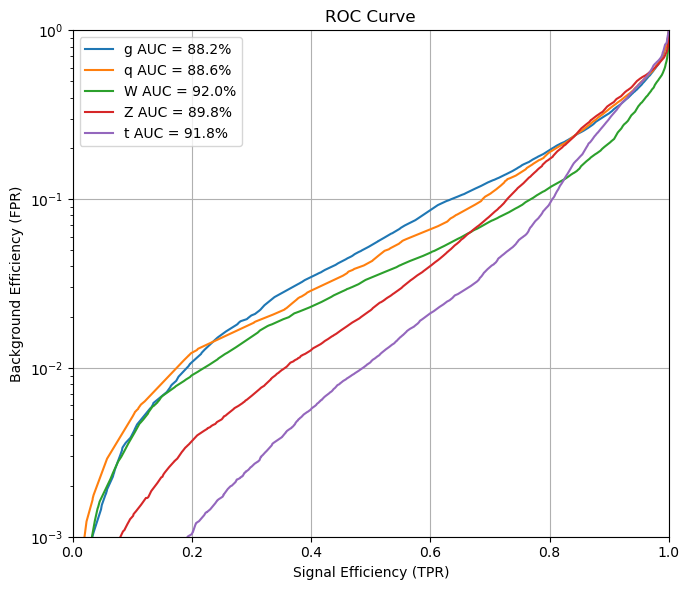

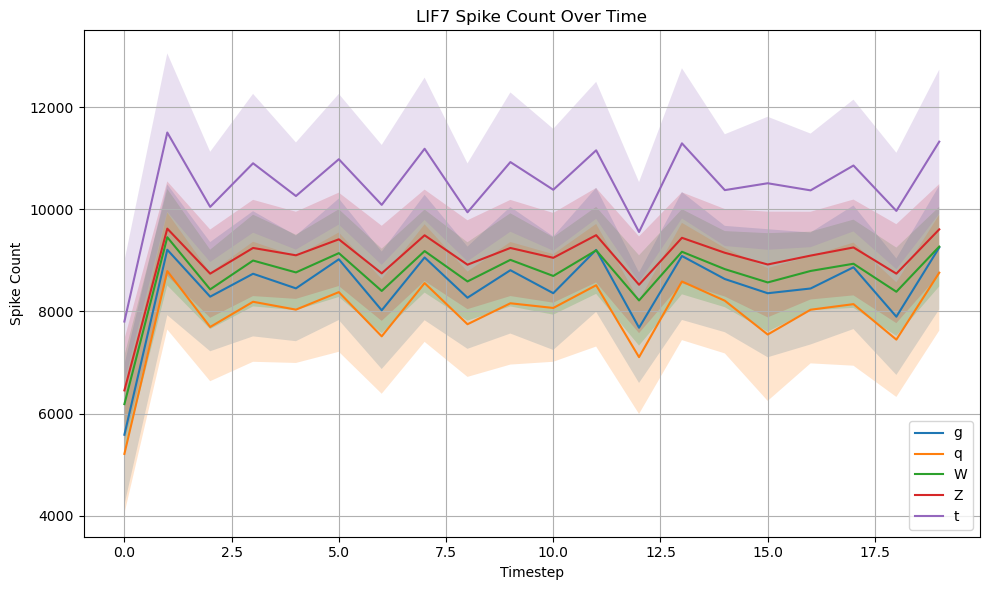

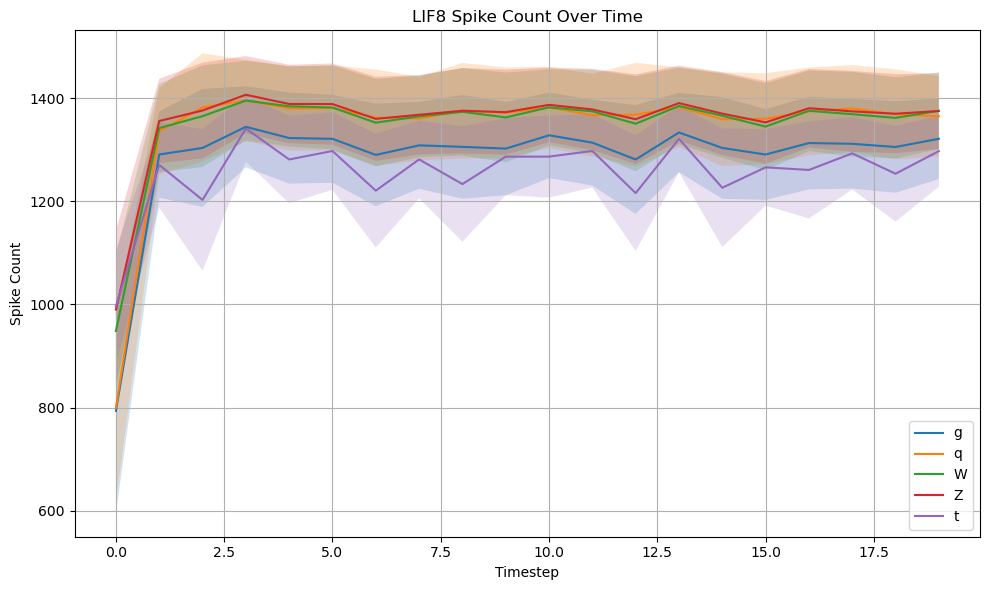

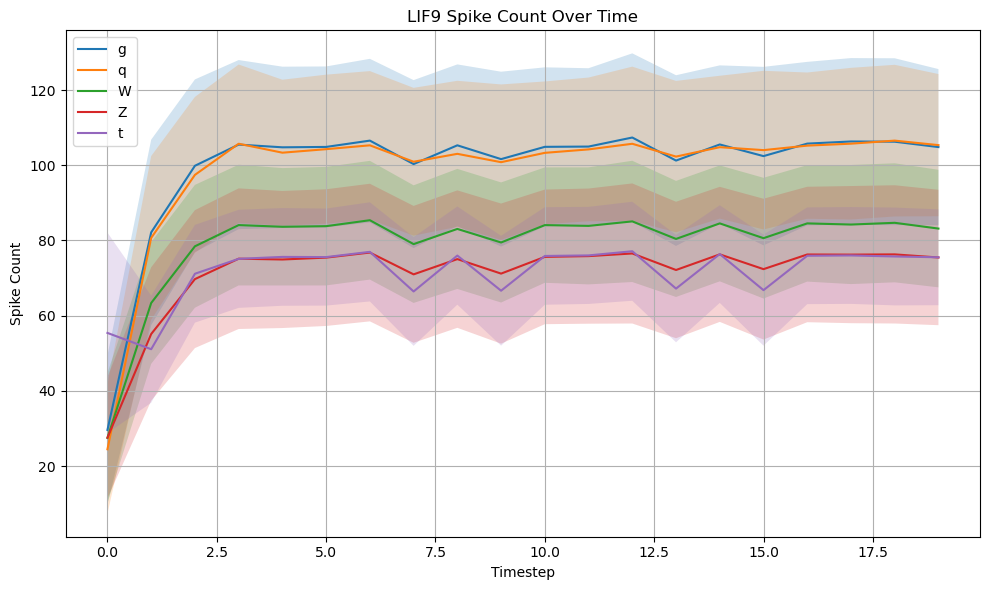

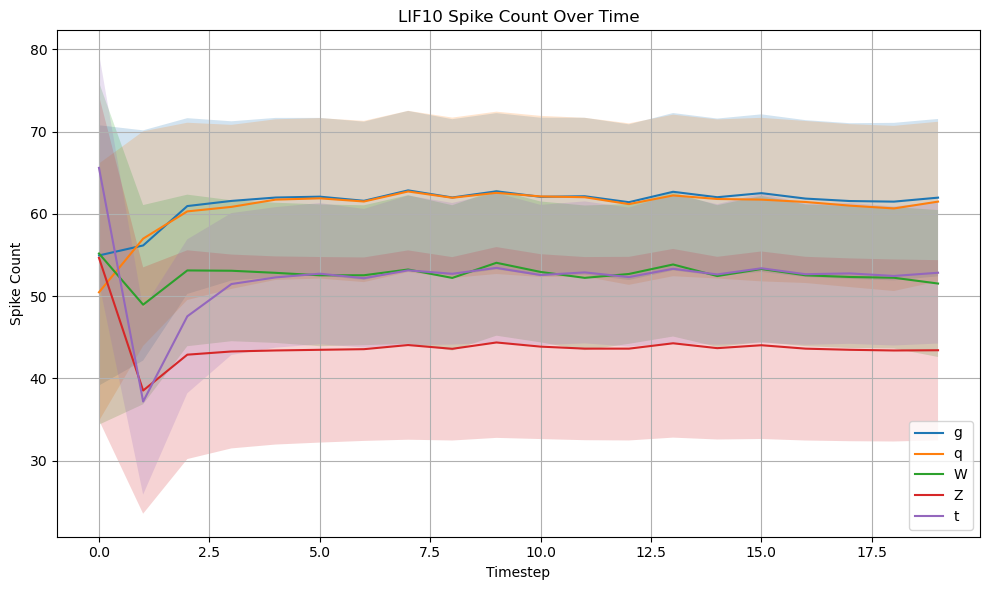

In [2]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from glob import glob
from tqdm import tqdm

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CHECKPOINT_DIR = "checkpoints_MLPSNNMixer_complex256_new"
RESULT_PATH = "results/MLPSNNMixer_complex256_new.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
NUM_TIMESTEPS = 20
BATCH_SIZE = 1024
NUM_EPOCHS = 100
PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === TRAINING STATE ===
start_epoch = 0
best_loss = float('inf')
early_counter = 0

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)
                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad)
                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

# === NORMALIZE ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)

# === TORCH DATASETS ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

# === UPDATED MODEL ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=256, num_classes=5, beta=0.5):
        super().__init__()

        # === Embedding Layer: 3 → 16 ===
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.lif0 = snn.Leaky(beta=beta)

        # === MLP1: Per-particle feature mixing ===
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif2 = snn.Leaky(beta=beta)

        # === MLP2: Mixing across particles ===
        self.fc3 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif4 = snn.Leaky(beta=beta)

        # === MLP3: Repeated per-particle mixing ===
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif6 = snn.Leaky(beta=beta)

        # === MLP4: Reduce across particles ===
        self.fc7 = nn.Linear(num_particles, hidden_dim)  # 10 → 16
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, num_particles)  # 16 → 10
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(num_particles, 1)           # 10 → 1
        self.lif9 = snn.Leaky(beta=beta)

        # === HEAD: Fully connected classifier ===
        self.fc10 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif10 = snn.Leaky(beta=beta)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim)  # 16 → 16
        self.lif11 = snn.Leaky(beta=beta)
        self.fc12 = nn.Linear(hidden_dim, num_classes)  # 16 → 5
        self.lif12 = snn.Leaky(beta=beta)
    
    def forward(self, x, num_steps=20):
        B = x.shape[0]
        spikes_out = []
    
        # === Initialize membrane states for all LIFs ===
        mem = {f"lif{i}": getattr(self, f"lif{i}").init_leaky() for i in range(13)}
    
        # === Initialize spike traces ===
        traces = {f"lif{i}": [] for i in range(13)}
    
        for _ in range(num_steps):
            # === Embedding ===
            x0 = self.embedding(x)
            spk0, mem['lif0'] = self.lif0(x0, mem['lif0'])
            traces['lif0'].append(spk0.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP1 ===
            x1 = self.fc1(spk0)
            spk1, mem['lif1'] = self.lif1(x1, mem['lif1'])
            traces['lif1'].append(spk1.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x2 = self.fc2(spk1)
            spk2, mem['lif2'] = self.lif2(x2, mem['lif2'])
            traces['lif2'].append(spk2.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP2 ===
            x2t = spk2.permute(0, 2, 1)
            x3 = self.fc3(x2t)
            spk3, mem['lif3'] = self.lif3(x3, mem['lif3'])
            traces['lif3'].append(spk3.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4 = self.fc4(spk3)
            spk4, mem['lif4'] = self.lif4(x4, mem['lif4'])
            traces['lif4'].append(spk4.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x4_out = spk4.permute(0, 2, 1)
    
            # === Residual Add ===
            x5 = spk0 + x4_out
    
            # === MLP3 ===
            x6 = self.fc5(x5)
            spk5, mem['lif5'] = self.lif5(x6, mem['lif5'])
            traces['lif5'].append(spk5.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x7 = self.fc6(spk5)
            spk6, mem['lif6'] = self.lif6(x7, mem['lif6'])
            traces['lif6'].append(spk6.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === MLP4 ===
            x7t = spk6.permute(0, 2, 1)
            x8 = self.fc7(x7t)
            spk7, mem['lif7'] = self.lif7(x8, mem['lif7'])
            traces['lif7'].append(spk7.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x9 = self.fc8(spk7)
            spk8, mem['lif8'] = self.lif8(x9, mem['lif8'])
            traces['lif8'].append(spk8.sum(dim=(1, 2)).detach().cpu().numpy())
    
            x10 = self.fc9(spk8)
            spk9, mem['lif9'] = self.lif9(x10, mem['lif9'])
            traces['lif9'].append(spk9.sum(dim=(1, 2)).detach().cpu().numpy())
    
            # === HEAD ===
            x11 = spk9.squeeze(-1)
            x12 = self.fc10(x11)
            spk10, mem['lif10'] = self.lif10(x12, mem['lif10'])
            traces['lif10'].append(spk10.sum(dim=1).detach().cpu().numpy())
    
            x13 = self.fc11(spk10)
            spk11, mem['lif11'] = self.lif11(x13, mem['lif11'])
            traces['lif11'].append(spk11.sum(dim=1).detach().cpu().numpy())
    
            x14 = self.fc12(spk11)
            spk12, mem['lif12'] = self.lif12(x14, mem['lif12'])
            traces['lif12'].append(spk12.sum(dim=1).detach().cpu().numpy())
    
            spikes_out.append(spk12)
    
        # Stack time axis for output and traces
        spikes_out = torch.stack(spikes_out, dim=2)  # (B, 5, T)
        traces = {k: np.stack(v, axis=1) for k, v in traces.items()}  # (B, T) per layer
    
        return spikes_out, traces

# === MODEL INIT ===
model = MLPMixerSNNHybrid().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# === LOAD CHECKPOINT IF AVAILABLE ===
checkpoint_files = sorted(glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pt")))
if checkpoint_files:
    latest_ckpt = checkpoint_files[-1]
    print(f"🔄 Loading checkpoint from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
else:
    print("ℹ️ No checkpoint found, starting from scratch.")


# === TRAINING LOOP ===
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack, _ = model(xb)
        out = out_stack.sum(dim=2)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc=f"Epoch {epoch+1} Validation"):
            xb, yb = xb.to(device), yb.to(device)
            out_stack, _ = model(xb)
            out = out_stack.sum(dim=2)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
    }, os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt"))

    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break
# === INFERENCE ===
y_pred, y_true_all = [], []
spike_logs = {k: [] for k in ["lif7", "lif8", "lif9", "lif10"]}

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out_stack, traces = model(xb)
        out = out_stack.sum(dim=2)
        y_pred.append(F.softmax(out, dim=1).cpu().numpy())
        y_true_all.append(yb.numpy())
        for k in spike_logs:
            spike_logs[k].append(traces[k])

y_pred = np.concatenate(y_pred, axis=0)
y_true = np.concatenate(y_true_all, axis=0)
y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
for k in spike_logs:
    spike_logs[k] = np.concatenate(spike_logs[k], axis=0)

# === SAVE
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_true_onehot, y_score=y_pred)

# === ROC CURVE
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, label=f"{name} AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === SPIKE PLOTS
for layer, data in spike_logs.items():
    plt.figure(figsize=(10, 6))
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_spikes = data[y_true == class_idx]
        mean = class_spikes.mean(axis=0)
        std = class_spikes.std(axis=0)
        plt.plot(mean, label=class_name)
        plt.fill_between(range(NUM_TIMESTEPS), mean - std, mean + std, alpha=0.2)
    plt.title(f"{layer.upper()} Spike Count Over Time")
    plt.xlabel("Timestep")
    plt.ylabel("Spike Count")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


✅ Loading cached constituent dataset...

Epoch 1/500


Validating: 100%|██████████| 264/264 [00:08<00:00, 30.74it/s]


Val loss: 1.0857 | Val acc: 0.5757

Epoch 2/500


Validating: 100%|██████████| 264/264 [00:08<00:00, 29.85it/s]


Val loss: 1.0560 | Val acc: 0.5911

Epoch 3/500


...

Val loss: 0.9583 | Val acc: 0.6505

Epoch 134/500


Validating: 100%|██████████| 264/264 [00:09<00:00, 29.29it/s]


Val loss: 0.9629 | Val acc: 0.6477
Early stopping.
✅ model.pth has been saved to: model.pth


Predicting: 100%|██████████| 264/264 [00:09<00:00, 28.59it/s]


✅ Results saved to results/snn_results_constituents.npz


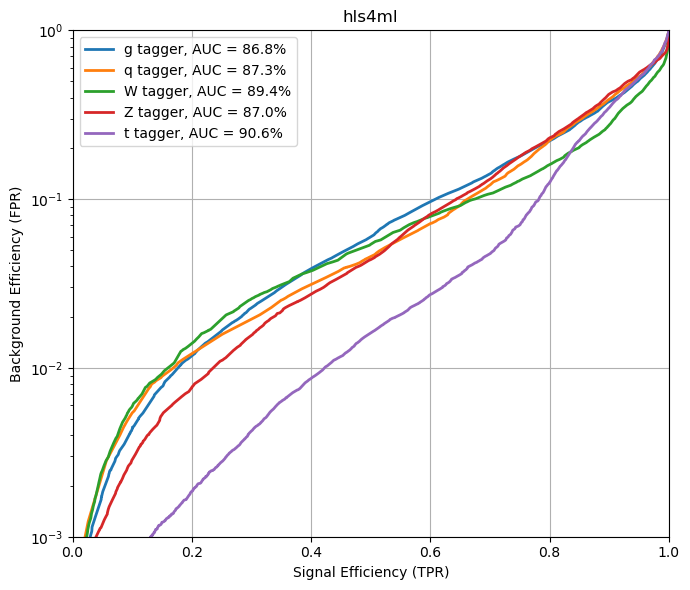

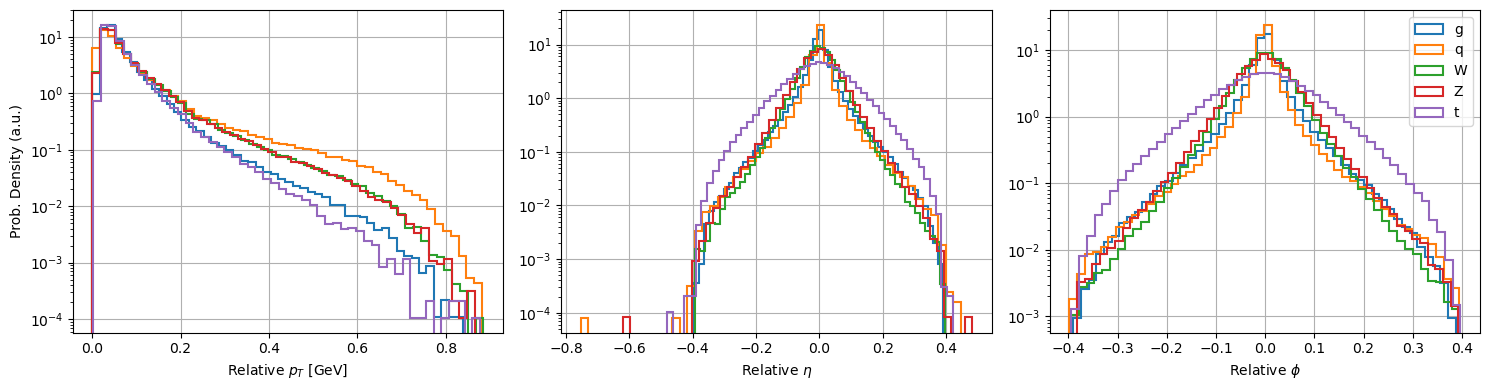

In [5]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
RESULT_PATH = "results/snn_results_constituents.npz"
MODEL_PATH = "model.pth"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
MAX_CONSTITUENTS = 10
FEATURE_IDX = [6, 8, 11]  # ptrel, etarel, phirel

# === Load and Cache Data ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning " + directory):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"])[:, :, FEATURE_IDX]
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)

                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad_width = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad_width)

                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"✅ Saved processed constituent dataset to: {CACHE_PATH}")

# === Normalize ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

# === Prepare Torch Datasets ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1024, shuffle=False)

# === Define Conv-SNN Model ===
class ConvSNN(nn.Module):
    def __init__(self, input_dim=3, beta=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(32 * MAX_CONSTITUENTS, 64)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(64, 5)
        self.lif3 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spk_out = []
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        x = x.permute(0, 2, 1)
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            flat = spk1.view(spk1.size(0), -1)
            cur2 = self.fc1(flat)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc2(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk_out.append(spk3)
        return torch.stack(spk_out, dim=2)

# === Training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvSNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
best_loss = float('inf')
early_counter = 0
patience = 20

for epoch in range(500):
    print(f"\nEpoch {epoch+1}/500")
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in tqdm(train_loader, desc="Training"):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out.sum(dim=2), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        pred = torch.argmax(out.sum(dim=2), dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    val_loss, val_correct, val_total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Validating"):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.sum(dim=2), yb)
            val_loss += loss.item() * xb.size(0)
            pred = torch.argmax(out.sum(dim=2), dim=1)
            val_correct += (pred == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model.state_dict()
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= patience:
            print("Early stopping.")
            break

# === Save best model ===
model.load_state_dict(best_model)
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ model.pth has been saved to: {MODEL_PATH}")

# === Predict & Save Results ===
model.eval()
y_pred = []
with torch.no_grad():
    for xb in tqdm(test_loader, desc="Predicting"):
        xb = xb[0].to(device)
        out = model(xb)
        probs = out.sum(dim=2).softmax(dim=1).cpu().numpy()
        y_pred.append(probs)

y_pred = np.concatenate(y_pred, axis=0)
np.savez_compressed(RESULT_PATH, y_true=y_test_tensor.numpy(), y_score=y_pred)
print(f"✅ Results saved to {RESULT_PATH}")

# === ROC Plot ===
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_tensor.numpy() == i, y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, lw=2, label=f"{name} tagger, AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("hls4ml")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Feature Distributions ===
feature_names = [r"Relative $p_T$ [GeV]", r"Relative $\eta$", r"Relative $\phi$"]
bins = 50
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    for j in range(5):
        mask = (y_test == j)
        values = X_test[mask, :, i].flatten()
        values = values[values != 0]
        plt.hist(values, bins=bins, density=True, histtype='step', label=CLASS_NAMES[j], color=colors[j], linewidth=1.5)
    plt.yscale('log')
    plt.xlabel(feature_names[i])
    if i == 0:
        plt.ylabel("Prob. Density (a.u.)")
    plt.grid(True)

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


In [6]:
import torch
import numpy as np
import os
import snntorch as snn
import torch.nn as nn

# === Match training architecture ===
MAX_CONSTITUENTS = 10

class ConvSNN(nn.Module):
    def __init__(self, input_dim=3, beta=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(32 * MAX_CONSTITUENTS, 64)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(64, 5)
        self.lif3 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spk_out = []
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        x = x.permute(0, 2, 1)
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            flat = spk1.view(spk1.size(0), -1)
            cur2 = self.fc1(flat)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc2(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk_out.append(spk3)
        return torch.stack(spk_out, dim=2)

# === Load trained model ===
model = ConvSNN()
model.load_state_dict(torch.load("model.pth", map_location="cpu"))
model.eval()

# === Extract conv1 weights [32 output channels, 3 input features] ===
weights = model.conv1.weight.detach().numpy().squeeze(-1)  # shape: [32, 3]

# === Helper to convert float to fixed-point hex (ap_int<32>) ===
def to_fixed_hex(w, width=32, frac_bits=8):
    scale = 2 ** frac_bits
    val = int(np.round(w * scale))
    if val < 0:
        val = (1 << width) + val
    return f"0x{val:08x}"

# === Write memdata.h ===
os.makedirs("hls_include", exist_ok=True)
with open("hls_include/memdata.h", "w") as f:
    f.write("#ifndef PARAMS_HPP\n#define PARAMS_HPP\n\n")
    f.write("#include \"ap_int.h\"\n\n")
    f.write("namespace PARAM {\n")
    f.write("static ap_int<32> conv1_weights[32][3] = {\n")
    for i in range(weights.shape[0]):
        row = ", ".join(to_fixed_hex(w) for w in weights[i])
        comma = "," if i < weights.shape[0] - 1 else ""
        f.write(f"  {{ {row} }}{comma}\n")
    f.write("};\n}  // namespace PARAM\n\n#endif\n")

print("✅ memdata.h successfully saved at: hls_include/memdata.h")


✅ memdata.h successfully saved at: hls_include/memdata.h


/tmp/ipykernel_126/3322870106.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pth", map_location="cpu"))


import torch
import numpy as np
import os
import snntorch as snn
import torch.nn as nn

# Match this with your architecture
MAX_CONSTITUENTS = 10

# === Model definition (same as training) ===
class ConvSNN(nn.Module):
    def __init__(self, input_dim=3, beta=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(32 * MAX_CONSTITUENTS, 64)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(64, 5)
        self.lif3 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spk_out = []
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        x = x.permute(0, 2, 1)
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            flat = spk1.view(spk1.size(0), -1)
            cur2 = self.fc1(flat)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc2(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk_out.append(spk3)
        return torch.stack(spk_out, dim=2)

# === Load the trained model ===
model = ConvSNN()
model.load_state_dict(torch.load("model.pth", map_location="cpu"))
model.eval()

# === Helper to convert float -> fixed-point hex ===
def to_fixed_hex(w, width=32, frac_bits=8):
    scale = 2 ** frac_bits
    val = int(np.round(w * scale))
    if val < 0:
        val = (1 << width) + val
    return f"0x{val:08x}"

# === Write FC weights to header ===
def write_fc_header(layer_weights, out_filename, varname):
    os.makedirs("hls_include", exist_ok=True)
    weight_np = layer_weights.weight.detach().numpy()
    bias_np = layer_weights.bias.detach().numpy()

    with open(out_filename, "w") as f:
        f.write("#ifndef PARAMS_HPP\n#define PARAMS_HPP\n\n")
        f.write("#include \"ap_int.h\"\n\n")
        f.write("namespace PARAM {\n")
        f.write(f"static ap_int<32> {varname}_weights[{weight_np.shape[0]}][{weight_np.shape[1]}] = {{\n")
        for i in range(weight_np.shape[0]):
            row = ", ".join(to_fixed_hex(w) for w in weight_np[i])
            comma = "," if i < weight_np.shape[0] - 1 else ""
            f.write(f"  {{ {row} }}{comma}\n")
        f.write("};\n\n")
        f.write(f"static ap_int<32> {varname}_bias[{bias_np.shape[0]}] = {{\n")
        bias_vals = ",\n  ".join(to_fixed_hex(b) for b in bias_np)
        f.write(f"  {bias_vals}\n")
        f.write("};\n}\n\n#endif\n")

# === Generate headers ===
write_fc_header(model.fc1, "hls_include/memdata_fc1.h", "fc1")
write_fc_header(model.fc2, "hls_include/memdata_fc2.h", "fc2")

print("✅ memdata_fc1.h and memdata_fc2.h written in hls_include/")


In [ ]:
AUC vs timesteps

/tmp/ipykernel_131/1581123591.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(latest, map_location=device)


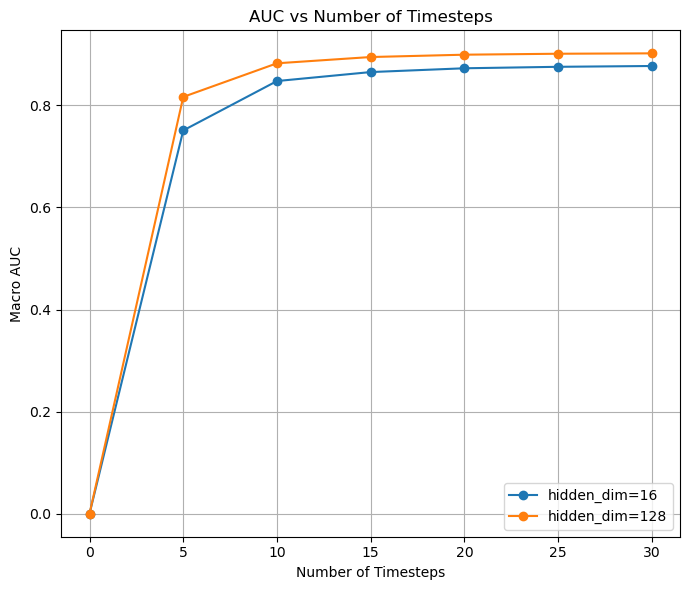

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from glob import glob
import h5py
from sklearn.preprocessing import StandardScaler
import snntorch as snn

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
BATCH_SIZE = 1024
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# timesteps to sweep
TIMESTEPS = list(range(0, 31, 5))

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        for fpath in sorted(glob(os.path.join(directory, "*.h5"))):
            with h5py.File(fpath, "r") as f:
                jets = np.array(f["jets"])
                constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                labels = jets[:, -6:-1]
                y = np.argmax(labels, axis=1)
                cons = constituents[:, :MAX_CONSTITUENTS, :]
                if cons.shape[1] < MAX_CONSTITUENTS:
                    pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                    cons = np.pad(cons, pad)
                X_list.append(cons)
                y_list.append(y)
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                         batch_size=BATCH_SIZE, shuffle=False)

# === MODEL DEF ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=16, num_classes=5, beta=0.5):
        super().__init__()
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.lif0 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc3 = nn.Linear(num_particles, hidden_dim)
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(hidden_dim, num_particles)
        self.lif4 = snn.Leaky(beta=beta)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)
        self.lif6 = snn.Leaky(beta=beta)
        self.fc7 = nn.Linear(num_particles, hidden_dim)
        self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, num_particles)
        self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(num_particles, 1)
        self.lif9 = snn.Leaky(beta=beta)
        self.fc10 = nn.Linear(hidden_dim, hidden_dim)
        self.lif10 = snn.Leaky(beta=beta)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim)
        self.lif11 = snn.Leaky(beta=beta)
        self.fc12 = nn.Linear(hidden_dim, num_classes)
        self.lif12 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spikes_out = []
        mem = {f"lif{i}": getattr(self, f"lif{i}").init_leaky() for i in range(13)}
        for _ in range(num_steps):
            x0 = self.embedding(x); spk0, mem['lif0'] = self.lif0(x0, mem['lif0'])
            x1 = self.fc1(spk0); spk1, mem['lif1'] = self.lif1(x1, mem['lif1'])
            x2 = self.fc2(spk1); spk2, mem['lif2'] = self.lif2(x2, mem['lif2'])
            x3 = self.fc3(spk2.permute(0, 2, 1)); spk3, mem['lif3'] = self.lif3(x3, mem['lif3'])
            x4 = self.fc4(spk3); spk4, mem['lif4'] = self.lif4(x4, mem['lif4'])
            x5 = spk0 + spk4.permute(0, 2, 1)
            x6 = self.fc5(x5); spk5, mem['lif5'] = self.lif5(x6, mem['lif5'])
            x7 = self.fc6(spk5); spk6, mem['lif6'] = self.lif6(x7, mem['lif6'])
            x8 = self.fc7(spk6.permute(0, 2, 1)); spk7, mem['lif7'] = self.lif7(x8, mem['lif7'])
            x9 = self.fc8(spk7); spk8, mem['lif8'] = self.lif8(x9, mem['lif8'])
            x10 = self.fc9(spk8); spk9, mem['lif9'] = self.lif9(x10, mem['lif9'])
            x11 = self.fc10(spk9.squeeze(-1)); spk10, mem['lif10'] = self.lif10(x11, mem['lif10'])
            x12 = self.fc11(spk10); spk11, mem['lif11'] = self.lif11(x12, mem['lif11'])
            x13 = self.fc12(spk11); spk12, mem['lif12'] = self.lif12(x13, mem['lif12'])
            spikes_out.append(spk12)
        return torch.stack(spikes_out, dim=2)  # (B, C, T)

# === LOAD MODELS ===
def load_model(hidden_dim, ckpt_dir):
    model = MLPMixerSNNHybrid(hidden_dim=hidden_dim, num_classes=NUM_CLASSES).to(device)
    ckpt_files = sorted(glob(os.path.join(ckpt_dir, "epoch_*.pt")))
    if not ckpt_files:
        raise FileNotFoundError(f"No checkpoints in {ckpt_dir}")
    latest = ckpt_files[-1]
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    return model

model16 = load_model(16, "checkpoints_MLPSNNMixer_complex")
model128 = load_model(128, "checkpoints_MLPSNNMixer_complex128")

# === EVAL AUC vs STEPS ===
def eval_auc_vs_steps(model):
    aucs = []
    for T in TIMESTEPS:
        if T == 0:
            aucs.append(0.0)
            continue
        y_true_all, y_pred_all = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out_stack = model(xb, num_steps=T)
                out = out_stack.sum(dim=2)
                y_pred_all.append(F.softmax(out, dim=1).cpu().numpy())
                y_true_all.append(yb.cpu().numpy())
        y_true = np.concatenate(y_true_all)
        y_pred = np.concatenate(y_pred_all)
        y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
        auc_macro = roc_auc_score(y_true_onehot, y_pred,
                                  average="macro", multi_class="ovr")
        aucs.append(auc_macro)
    return aucs

aucs_16 = eval_auc_vs_steps(model16)
aucs_128 = eval_auc_vs_steps(model128)

# === PLOT ===
plt.figure(figsize=(7, 6))
plt.plot(TIMESTEPS, aucs_16, marker="o", label="hidden_dim=16")
plt.plot(TIMESTEPS, aucs_128, marker="o", label="hidden_dim=128")
plt.xlabel("Number of Timesteps")
plt.ylabel("Macro AUC")
plt.title("AUC vs Number of Timesteps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_131/2455653936.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpts[-1], map_location=device)


🔍 Evaluating hidden_dim=64...
🔍 Evaluating hidden_dim=128...
🔍 Evaluating hidden_dim=256...


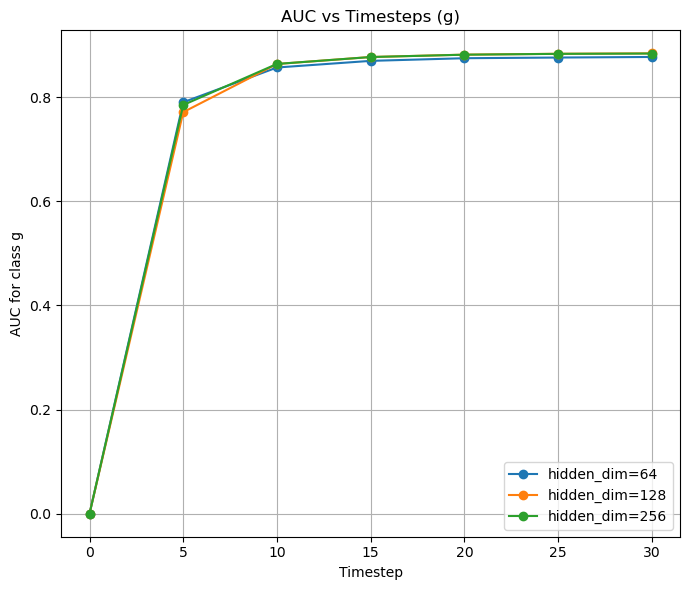

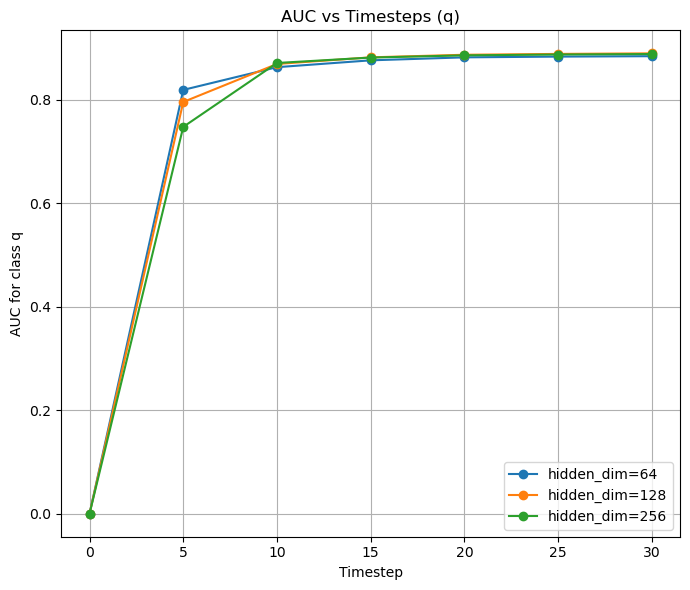

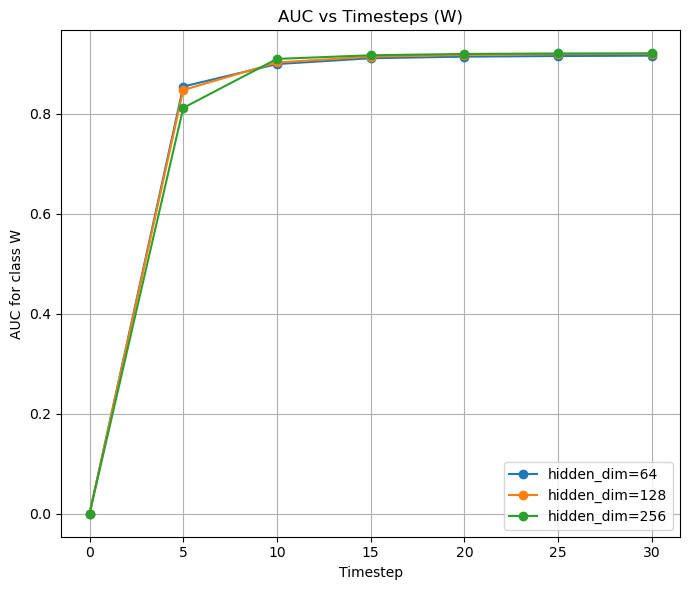

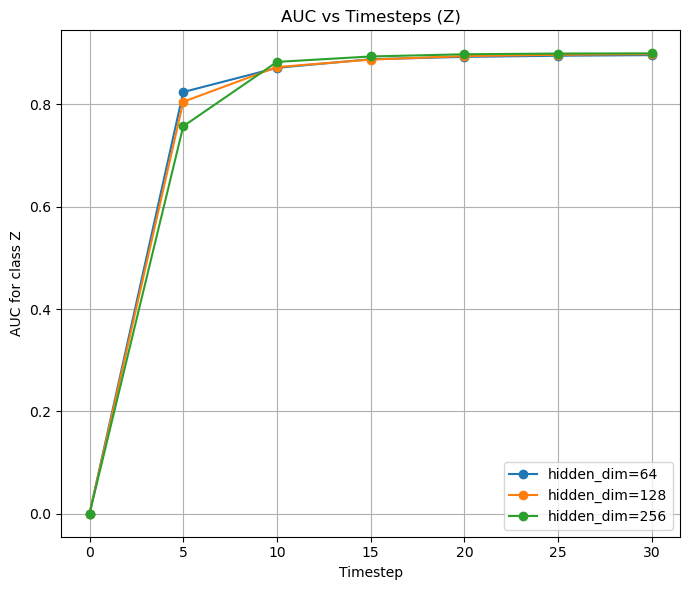

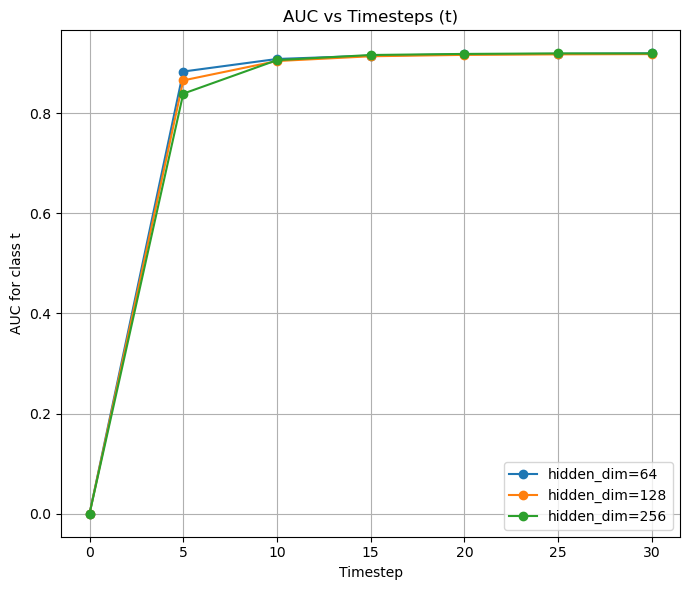

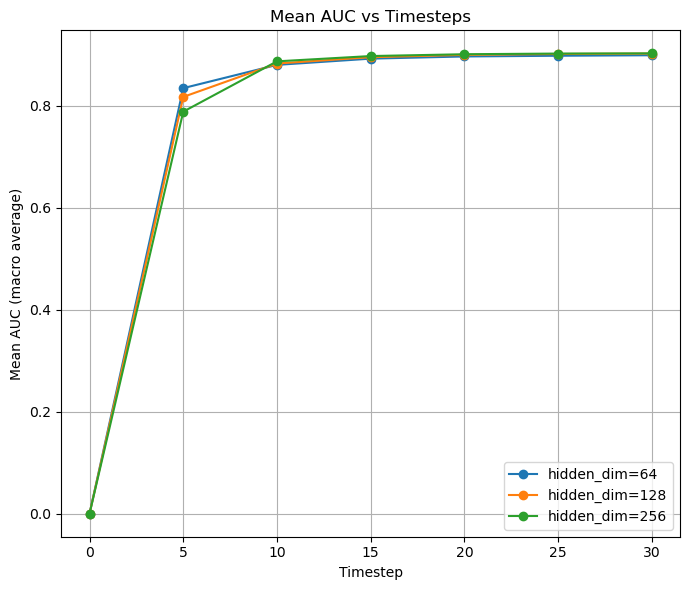

In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from glob import glob
import h5py
from sklearn.preprocessing import StandardScaler
import snntorch as snn

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
BATCH_SIZE = 1024
TIMESTEPS = list(range(0, 31, 5))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    data = np.load(CACHE_PATH)
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        for fpath in sorted(glob(os.path.join(directory, "*.h5"))):
            with h5py.File(fpath, "r") as f:
                jets = np.array(f["jets"])
                constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                labels = jets[:, -6:-1]
                y = np.argmax(labels, axis=1)
                cons = constituents[:, :MAX_CONSTITUENTS, :]
                if cons.shape[1] < MAX_CONSTITUENTS:
                    pad = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                    cons = np.pad(cons, pad)
                X_list.append(cons)
                y_list.append(y)
        return np.concatenate(X_list), np.concatenate(y_list)

    _, _ = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)
    np.savez_compressed(CACHE_PATH, X_test=X_test, y_test=y_test)

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE)

# === MODEL DEF ===
class MLPMixerSNNHybrid(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=128, num_classes=5, beta=0.5):
        super().__init__()
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.lif0 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim); self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim); self.lif2 = snn.Leaky(beta=beta)
        self.fc3 = nn.Linear(num_particles, hidden_dim); self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(hidden_dim, num_particles); self.lif4 = snn.Leaky(beta=beta)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim); self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim); self.lif6 = snn.Leaky(beta=beta)
        self.fc7 = nn.Linear(num_particles, hidden_dim); self.lif7 = snn.Leaky(beta=beta)
        self.fc8 = nn.Linear(hidden_dim, num_particles); self.lif8 = snn.Leaky(beta=beta)
        self.fc9 = nn.Linear(num_particles, 1); self.lif9 = snn.Leaky(beta=beta)
        self.fc10 = nn.Linear(hidden_dim, hidden_dim); self.lif10 = snn.Leaky(beta=beta)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim); self.lif11 = snn.Leaky(beta=beta)
        self.fc12 = nn.Linear(hidden_dim, num_classes); self.lif12 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spikes_out = []
        mem = {f"lif{i}": getattr(self, f"lif{i}").init_leaky() for i in range(13)}
        for _ in range(num_steps):
            x0 = self.embedding(x); spk0, mem['lif0'] = self.lif0(x0, mem['lif0'])
            x1 = self.fc1(spk0); spk1, mem['lif1'] = self.lif1(x1, mem['lif1'])
            x2 = self.fc2(spk1); spk2, mem['lif2'] = self.lif2(x2, mem['lif2'])
            x3 = self.fc3(spk2.permute(0, 2, 1)); spk3, mem['lif3'] = self.lif3(x3, mem['lif3'])
            x4 = self.fc4(spk3); spk4, mem['lif4'] = self.lif4(x4, mem['lif4'])
            x5 = spk0 + spk4.permute(0, 2, 1)
            x6 = self.fc5(x5); spk5, mem['lif5'] = self.lif5(x6, mem['lif5'])
            x7 = self.fc6(spk5); spk6, mem['lif6'] = self.lif6(x7, mem['lif6'])
            x8 = self.fc7(spk6.permute(0, 2, 1)); spk7, mem['lif7'] = self.lif7(x8, mem['lif7'])
            x9 = self.fc8(spk7); spk8, mem['lif8'] = self.lif8(x9, mem['lif8'])
            x10 = self.fc9(spk8); spk9, mem['lif9'] = self.lif9(x10, mem['lif9'])
            x11 = self.fc10(spk9.squeeze(-1)); spk10, mem['lif10'] = self.lif10(x11, mem['lif10'])
            x12 = self.fc11(spk10); spk11, mem['lif11'] = self.lif11(x12, mem['lif11'])
            x13 = self.fc12(spk11); spk12, mem['lif12'] = self.lif12(x13, mem['lif12'])
            spikes_out.append(spk12)
        return torch.stack(spikes_out, dim=2)

# === LOAD MODEL FROM CHECKPOINT ===
def load_model(hidden_dim, ckpt_dir):
    model = MLPMixerSNNHybrid(hidden_dim=hidden_dim).to(device)
    ckpts = sorted(glob(os.path.join(ckpt_dir, "epoch_*.pt")))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoint in {ckpt_dir}")
    ckpt = torch.load(ckpts[-1], map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model

# === EVAL FUNCTION ===
def eval_model_auc(model, timesteps):
    per_class_aucs = {T: [] for T in timesteps}
    for T in timesteps:
        if T == 0:
            per_class_aucs[T] = [0.0] * NUM_CLASSES
            continue
        y_preds, y_trues = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb, num_steps=T).sum(dim=2)
                y_preds.append(F.softmax(out, dim=1).cpu().numpy())
                y_trues.append(yb.cpu().numpy())
        y_pred = np.concatenate(y_preds)
        y_true = np.concatenate(y_trues)
        y_true_1h = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
        for i in range(NUM_CLASSES):
            try:
                auc_i = roc_auc_score(y_true_1h[:, i], y_pred[:, i])
            except:
                auc_i = 0.0
            per_class_aucs[T].append(auc_i)
    return per_class_aucs

# === RUN FOR ALL MODELS ===
models = {
    64: load_model(64, "checkpoints_MLPSNNMixer_complex64"),
    128: load_model(128, "checkpoints_MLPSNNMixer_complex128"),
    256: load_model(256, "checkpoints_MLPSNNMixer_complex256_new"),
}

results = {}
for dim, model in models.items():
    print(f"🔍 Evaluating hidden_dim={dim}...")
    results[dim] = eval_model_auc(model, TIMESTEPS)

# === PLOT PER-CLASS AUC ===
for class_idx, class_name in enumerate(CLASS_NAMES):
    plt.figure(figsize=(7, 6))
    for dim in sorted(results):
        aucs = [results[dim][t][class_idx] for t in TIMESTEPS]
        plt.plot(TIMESTEPS, aucs, marker="o", label=f"hidden_dim={dim}")
    plt.xlabel("Timestep")
    plt.ylabel(f"AUC for class {class_name}")
    plt.title(f"AUC vs Timesteps ({class_name})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# === PLOT MEAN AUC ===
plt.figure(figsize=(7, 6))
for dim in sorted(results):
    aucs = [np.mean(results[dim][t]) for t in TIMESTEPS]
    plt.plot(TIMESTEPS, aucs, marker="o", label=f"hidden_dim={dim}")
plt.xlabel("Timestep")
plt.ylabel("Mean AUC (macro average)")
plt.title("Mean AUC vs Timesteps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_131/2893492101.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))
/tmp/ipykernel_131/2893492101

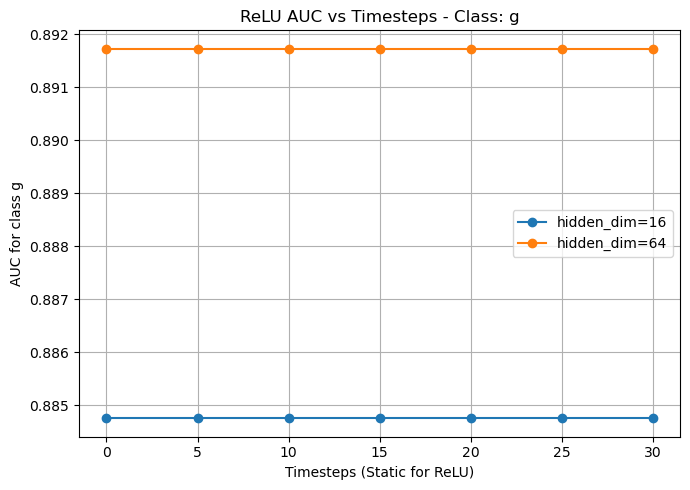

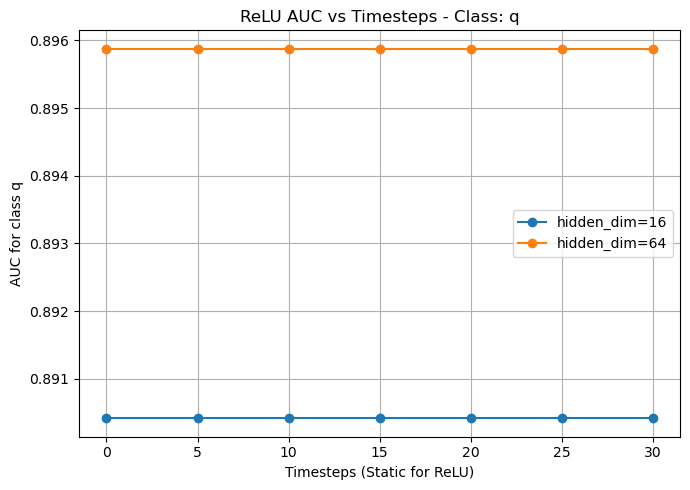

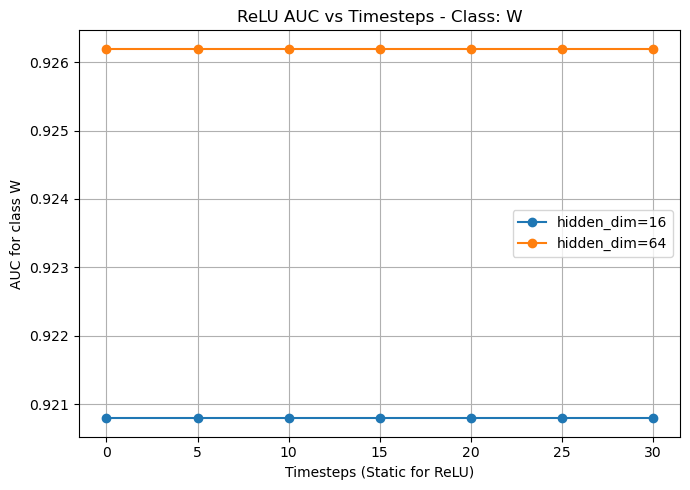

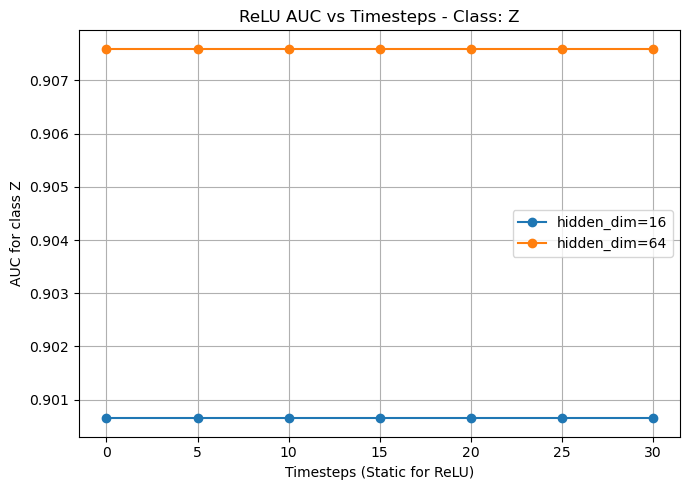

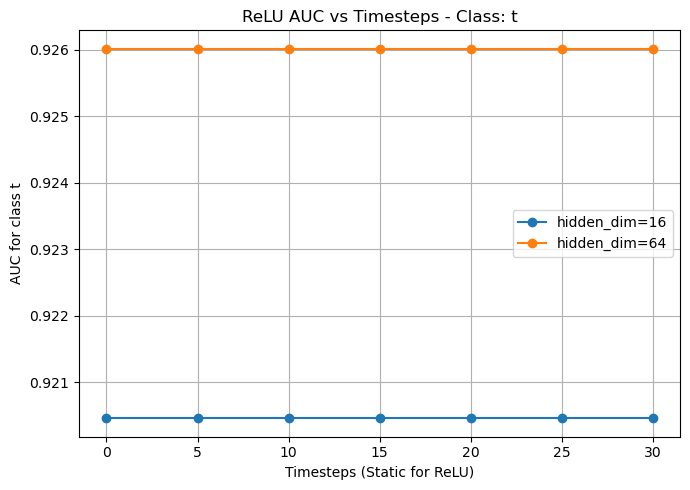

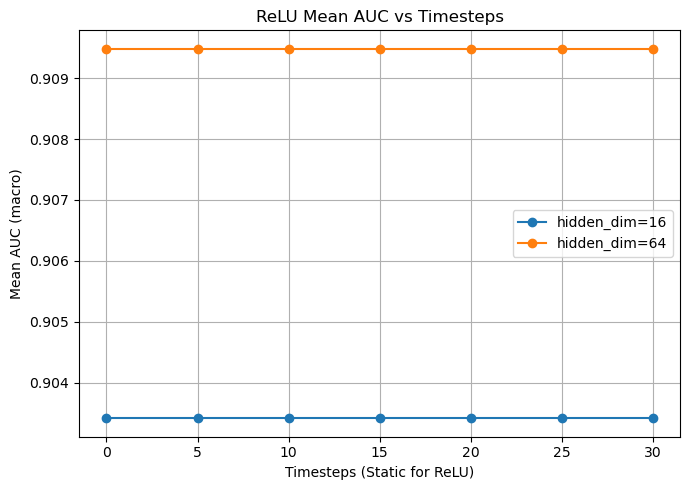

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from glob import glob
import h5py

# === CONFIG ===
CACHE_PATH = "cached_data/jet_constituents.npz"
CHECKPOINTS = {
    16: "checkpoints_MLPMixerRELU_complex16/best.pt",
    64: "checkpoints_MLPMixerRELU_complex/best.pt"
}
TIMESTEPS = list(range(0, 31, 5))  # even though ReLU is static
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
FEATURE_IDX = [6, 8, 11]
MAX_CONSTITUENTS = 10
NUM_CLASSES = 5
BATCH_SIZE = 1024
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === LOAD DATA ===
if os.path.exists(CACHE_PATH):
    data = np.load(CACHE_PATH)
    X_test, y_test = data["X_test"], data["y_test"]
else:
    raise FileNotFoundError("Missing preprocessed data. Run training or preprocessing first.")

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE)

# === MODEL ===
class MLPMixerReLU(nn.Module):
    def __init__(self, num_particles=10, num_features=3, hidden_dim=64, num_classes=5):
        super().__init__()
        self.embedding = nn.Linear(num_features, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(num_particles, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, num_particles)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)
        self.fc7 = nn.Linear(num_particles, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, num_particles)
        self.fc9 = nn.Linear(num_particles, 1)
        self.fc10 = nn.Linear(hidden_dim, hidden_dim)
        self.fc11 = nn.Linear(hidden_dim, hidden_dim)
        self.fc12 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x0 = F.relu(self.embedding(x))
        x1 = F.relu(self.fc1(x0))
        x2 = F.relu(self.fc2(x1))
        x2t = x2.permute(0, 2, 1)
        x3 = F.relu(self.fc3(x2t))
        x4 = F.relu(self.fc4(x3))
        x4_out = x4.permute(0, 2, 1)
        x5 = x0 + x4_out
        x6 = F.relu(self.fc5(x5))
        x7 = F.relu(self.fc6(x6))
        x7t = x7.permute(0, 2, 1)
        x8 = F.relu(self.fc7(x7t))
        x9 = F.relu(self.fc8(x8))
        x10 = self.fc9(x9).squeeze(-1)
        x11 = F.relu(self.fc10(x10))
        x12 = F.relu(self.fc11(x11))
        x13 = self.fc12(x12)
        return x13

# === EVALUATION ===
def evaluate(model):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            y_pred.append(F.softmax(logits, dim=1).cpu().numpy())
            y_true.append(yb.cpu().numpy())
    y_pred = np.concatenate(y_pred)
    y_true = np.concatenate(y_true)
    y_true_onehot = F.one_hot(torch.tensor(y_true), NUM_CLASSES).numpy()
    return y_pred, y_true_onehot

# === MAIN LOOP ===
results = {}
for hidden_dim, path in CHECKPOINTS.items():
    model = MLPMixerReLU(hidden_dim=hidden_dim).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    y_pred, y_true = evaluate(model)

    aucs_per_class = []
    for i in range(NUM_CLASSES):
        try:
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        except:
            auc = 0.0
        aucs_per_class.append(auc)

    results[hidden_dim] = {
        "macro_auc": np.mean(aucs_per_class),
        "per_class_auc": aucs_per_class
    }

# === PLOT PER CLASS ===
for i, class_name in enumerate(CLASS_NAMES):
    plt.figure(figsize=(7, 5))
    for dim in sorted(results):
        y = [results[dim]["per_class_auc"][i]] * len(TIMESTEPS)
        plt.plot(TIMESTEPS, y, marker='o', label=f"hidden_dim={dim}")
    plt.xlabel("Timesteps (Static for ReLU)")
    plt.ylabel(f"AUC for class {class_name}")
    plt.title(f"ReLU AUC vs Timesteps - Class: {class_name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# === PLOT MEAN AUC ===
plt.figure(figsize=(7, 5))
for dim in sorted(results):
    y = [results[dim]["macro_auc"]] * len(TIMESTEPS)
    plt.plot(TIMESTEPS, y, marker='o', label=f"hidden_dim={dim}")
plt.xlabel("Timesteps (Static for ReLU)")
plt.ylabel("Mean AUC (macro)")
plt.title("ReLU Mean AUC vs Timesteps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
